# NGHIÊN CỨU ĐỐI SÁNH HIỆU NĂNG 5 KIẾN TRÚC DEEP LEARNING 1D & GIẢI THÍCH MÔ HÌNH VỚI 1D GRAD-CAM CHO CHẨN ĐOÁN RỐI LOẠN NHỊP TIM (ECG)

> **Đề tài**: Hệ thống Giám sát Điện tâm đồ Thời gian thực & Phát hiện Rối loạn Nhịp tim ứng dụng Học sâu và Trí tuệ Nhân tạo Giải thích được (XAI).  
> **Tiêu chuẩn Y tế**: Tiêu chuẩn 5 lớp AAMI EC57 (Normal, Supraventricular, Ventricular, Fusion, Unknown).  
> **Tác giả / Nhóm nghiên cứu**: Dự án ECG Arrhythmia Detection & XAI  
> **Mục tiêu Notebook**:
> 1. Xây dựng nền tảng toán học chặt chẽ cho các chỉ số đánh giá y tế: Precision, Recall, Specificity, F1-Score (Macro, Micro, Weighted).
> 2. Thực nghiệm đối sánh độc lập 5 trường phái kiến trúc Deep Learning 1D (ResNet1D, CNN-LSTM, TCN, Transformer1D, Mamba1D) trên 21.892 nhịp test thực tế.
> 3. Chứng minh vì sao chọn **ResNet1D** làm mô hình Production (Accuracy 98.43%, F1-Macro 91.70%, Latency 0.13 ms).
> 4. Phân tích bản chất toán học và ý nghĩa lâm sàng của **1D Grad-CAM**, định lượng độ chính xác của Heatmap qua phương pháp Pointing Game.
> 5. Phân tích nguyên nhân khoa học khiến Recall lớp S sụp đổ (0.4% - 3.6%) khi kiểm chứng trên dữ liệu độc lập (SVDB, EDB) trong khi lớp V vẫn đạt 78% - 96%.
> 6. Đánh giá lượng hóa mô hình ONNX FP32 / INT8 và định hướng kiến trúc tối ưu cho vi điều khiển nhúng (ESP32) trong tương lai.


---
## 1. Cơ Sở Toán Học & Công Thức Tính Các Chỉ Số Đánh Giá (Evaluation Metrics)

Trong phân loại tín hiệu y sinh, đặc biệt là điện tâm đồ (ECG), tập dữ liệu luôn bị **mất cân bằng cực kỳ nghiêm trọng** (lớp nhịp bình thường $N$ chiếm $>80\%$, các lớp bệnh lý nguy hiểm $S, V, F$ chỉ chiếm từ $0.7\%$ đến $6\%$). 

Nếu chỉ dựa vào **Accuracy (Độ chính xác tổng quan)**, một mô hình tầm thường chỉ cần luôn luôn dự đoán nhãn là "Bình thường" ($N$) cũng sẽ đạt Accuracy $>82\%$, nhưng bỏ sót $100\%$ bệnh nhân có nguy cơ đột tử. Vì vậy, các chỉ số sau đây là bắt buộc phải được tính toán và phân tích đa chiều:

### 1.1. Ma Trận Nhầm Lẫn Đa Lớp (One-vs-Rest Formulation)
Với bài toán 5 lớp AAMI $c \in \{0, 1, 2, 3, 4\}$, với mỗi lớp $c$, ta xác định 4 đại lượng:
* **$TP_c$ (True Positive)**: Số mẫu nhịp thuộc lớp $c$ được mô hình dự đoán chính xác là lớp $c$.
* **$FP_c$ (False Positive - Dương tính giả)**: Số mẫu nhịp **không** thuộc lớp $c$ nhưng bị mô hình báo động nhầm thành lớp $c$ (Gây hoang mang, quá tải điều dưỡng).
* **$FN_c$ (False Negative - Âm tính giả)**: Số mẫu nhịp thực sự là lớp $c$ nhưng mô hình bỏ sót, đoán thành lớp khác (Cực kỳ nguy hiểm, có thể dẫn đến tử vong).
* **$TN_c$ (True Negative - Âm tính đúng)**: Số mẫu nhịp không phải lớp $c$ và mô hình cũng xác nhận không phải lớp $c$.

### 1.2. Công Thức Từng Lớp (Per-Class Metrics)
1. **Precision (Độ chuẩn xác / Giá trị dự đoán dương tính - PPV)**:
   $$\\text{Precision}_c = \\frac{TP_c}{TP_c + FP_c}$$
   *Ý nghĩa lâm sàng*: Khi hệ thống phát chuông cảnh báo nhịp thất $V$, có bao nhiêu phần trăm khả năng bệnh nhân thực sự bị ngoại tâm thu thất? Precision cao giúp giảm thiểu hiện tượng "mệt mỏi vì chuông báo" (*alarm fatigue*) trong bệnh viện.

2. **Recall / Sensitivity (Độ nhạy / Độ bao phủ bệnh)**:
   $$\\text{Recall}_c = \\frac{TP_c}{TP_c + FN_c}$$
   *Ý nghĩa lâm sàng*: Trong số tất cả các nhịp bệnh lý thực tế của bệnh nhân, hệ thống phát hiện được bao nhiêu phần trăm? Trong y tế, Recall luôn được ưu tiên cao nhất để không bỏ sót ca bệnh.

3. **Specificity (Độ đặc hiệu - True Negative Rate)**:
   $$\\text{Specificity}_c = \\frac{TN_c}{TN_c + FP_c}$$
   *Ý nghĩa lâm sàng*: Khả năng nhận diện chính xác các trạng thái không mang mầm bệnh của lớp đó.

4. **$F_1$-Score (Điểm số F1 - Trung bình điều hòa giữa Precision và Recall)**:
   $$F_{1, c} = 2 \\times \\frac{\\text{Precision}_c \\times \\text{Recall}_c}{\\text{Precision}_c + \\text{Recall}_c} = \\frac{2 TP_c}{2 TP_c + FP_c + FN_c}$$
   *Vì sao dùng trung bình điều hòa (Harmonic Mean)?* Vì trung bình điều hòa phạt rất nặng nếu một trong hai chỉ số (Precision hoặc Recall) bị thấp. Nếu một mô hình có Recall $99\%$ nhưng Precision chỉ $10\\%$, điểm $F_1$ sẽ bị kéo tụt xuống $\\approx 18\\%$, phản ánh đúng chất lượng kém của mô hình.

### 1.3. Phương Pháp Tổng Hợp Đa Lớp (Multi-Class Aggregation)
Với $C = 5$ lớp AAMI:
1. **Macro-Average $F_1$ ($F_1^{\\text{macro}}$ - Tiêu chuẩn vàng của đề cương)**:
   $$F_1^{\\text{macro}} = \\frac{1}{C} \\sum_{c=0}^{C-1} F_{1, c}$$
   *Đặc điểm*: Coi mọi lớp bệnh có tầm quan trọng ngang nhau, không phụ thuộc vào số lượng mẫu nhiều hay ít. Một mô hình muốn đạt $F_1^{\\text{macro}} > 90\\%$ bắt buộc phải chẩn đoán xuất sắc cả lớp hiếm gặp như $F$ (chỉ $162$ mẫu) lẫn lớp phổ biến $N$ ($18,118$ mẫu).

2. **Micro-Average $F_1$ ($F_1^{\\text{micro}}$)**:
   $$F_1^{\\text{micro}} = \\frac{2 \\sum_{c=0}^{C-1} TP_c}{2 \\sum_{c=0}^{C-1} TP_c + \\sum_{c=0}^{C-1} FP_c + \\sum_{c=0}^{C-1} FN_c} = \\text{Accuracy}$$

3. **Weighted-Average $F_1$ ($F_1^{\\text{weighted}}$)**:
   $$F_1^{\\text{weighted}} = \\sum_{c=0}^{C-1} \\left(\\frac{N_c}{N_{\\text{total}}}\\right) F_{1, c}$$


---
## 2. Nạp Dữ Liệu & Khảo Sát Hình Thái Tín Hiệu (Exploratory Data Analysis)

Dữ liệu đầu vào chuẩn hóa được nạp từ `data/processed/X_test_kaggle.npy` và `y_test_kaggle.npy`:
* Tần số lấy mẫu đã chuyển đổi: **$125\\text{ Hz}$**.
* Độ dài cửa sổ cố định: **$187\\text{ mẫu/nhịp}$** (Bắt đầu từ đỉnh R, cắt động theo chu kỳ RR và zero-padded).
* Biên độ chuẩn hóa: $[0.0, 1.0]$.
* Chuẩn 5 lớp AAMI:
  * **0 - N**: Nhịp bình thường (*Normal*)
  * **1 - S**: Nhịp ngoại tâm thu trên thất (*Supraventricular*)
  * **2 - V**: Nhịp ngoại tâm thu thất / PVC (*Ventricular*)
  * **3 - F**: Nhịp hợp nhất (*Fusion*)
  * **4 - Q**: Nhịp chưa phân loại / Có máy tạo nhịp (*Unknown / Paced*)


In [15]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# Thiết lập đường dẫn môi trường
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.append(os.path.join(BASE_DIR, "src"))

from models import ResNet1D, CNN1D_LSTM, TemporalConvNet, Transformer1D, Mamba1D
from xai.gradcam1d import GradCAM1D, Saliency1D

# Nạp tập dữ liệu kiểm thử độc lập
X_test = np.load(os.path.join(BASE_DIR, "data", "processed", "X_test_kaggle.npy"))
y_test = np.load(os.path.join(BASE_DIR, "data", "processed", "y_test_kaggle.npy"))

print(f"[✓] Đã nạp thành công tập Test:")
print(f"    - Kích thước tín hiệu: {X_test.shape} (21,892 nhịp tim, 187 điểm/nhịp)")
print(f"    - Phân phối 5 lớp AAMI thực tế:")
counts = np.bincount(y_test)
class_labels = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']
for c, cnt in enumerate(counts):
    print(f"      • Lớp {c} [{class_labels[c]:22s}]: {cnt:6,d} mẫu ({cnt/len(y_test)*100:5.2f}%)")


[✓] Đã nạp thành công tập Test:
    - Kích thước tín hiệu: (21892, 187) (21,892 nhịp tim, 187 điểm/nhịp)
    - Phân phối 5 lớp AAMI thực tế:
      • Lớp 0 [N (Normal)            ]: 18,118 mẫu (82.76%)
      • Lớp 1 [S (Supraventricular)  ]:    556 mẫu ( 2.54%)
      • Lớp 2 [V (Ventricular)       ]:  1,448 mẫu ( 6.61%)
      • Lớp 3 [F (Fusion)            ]:    162 mẫu ( 0.74%)
      • Lớp 4 [Q (Unknown)           ]:  1,608 mẫu ( 7.35%)


### Trực Quan Hóa Hình Thái Sóng ECG Của 5 Lớp & Tác Động Của SMOTE
Đồ thị dưới đây minh họa sự khác biệt hình thái giữa các dạng sóng và biểu đồ phân phối mẫu trước/sau khi cân bằng bằng kỹ thuật SMOTE:


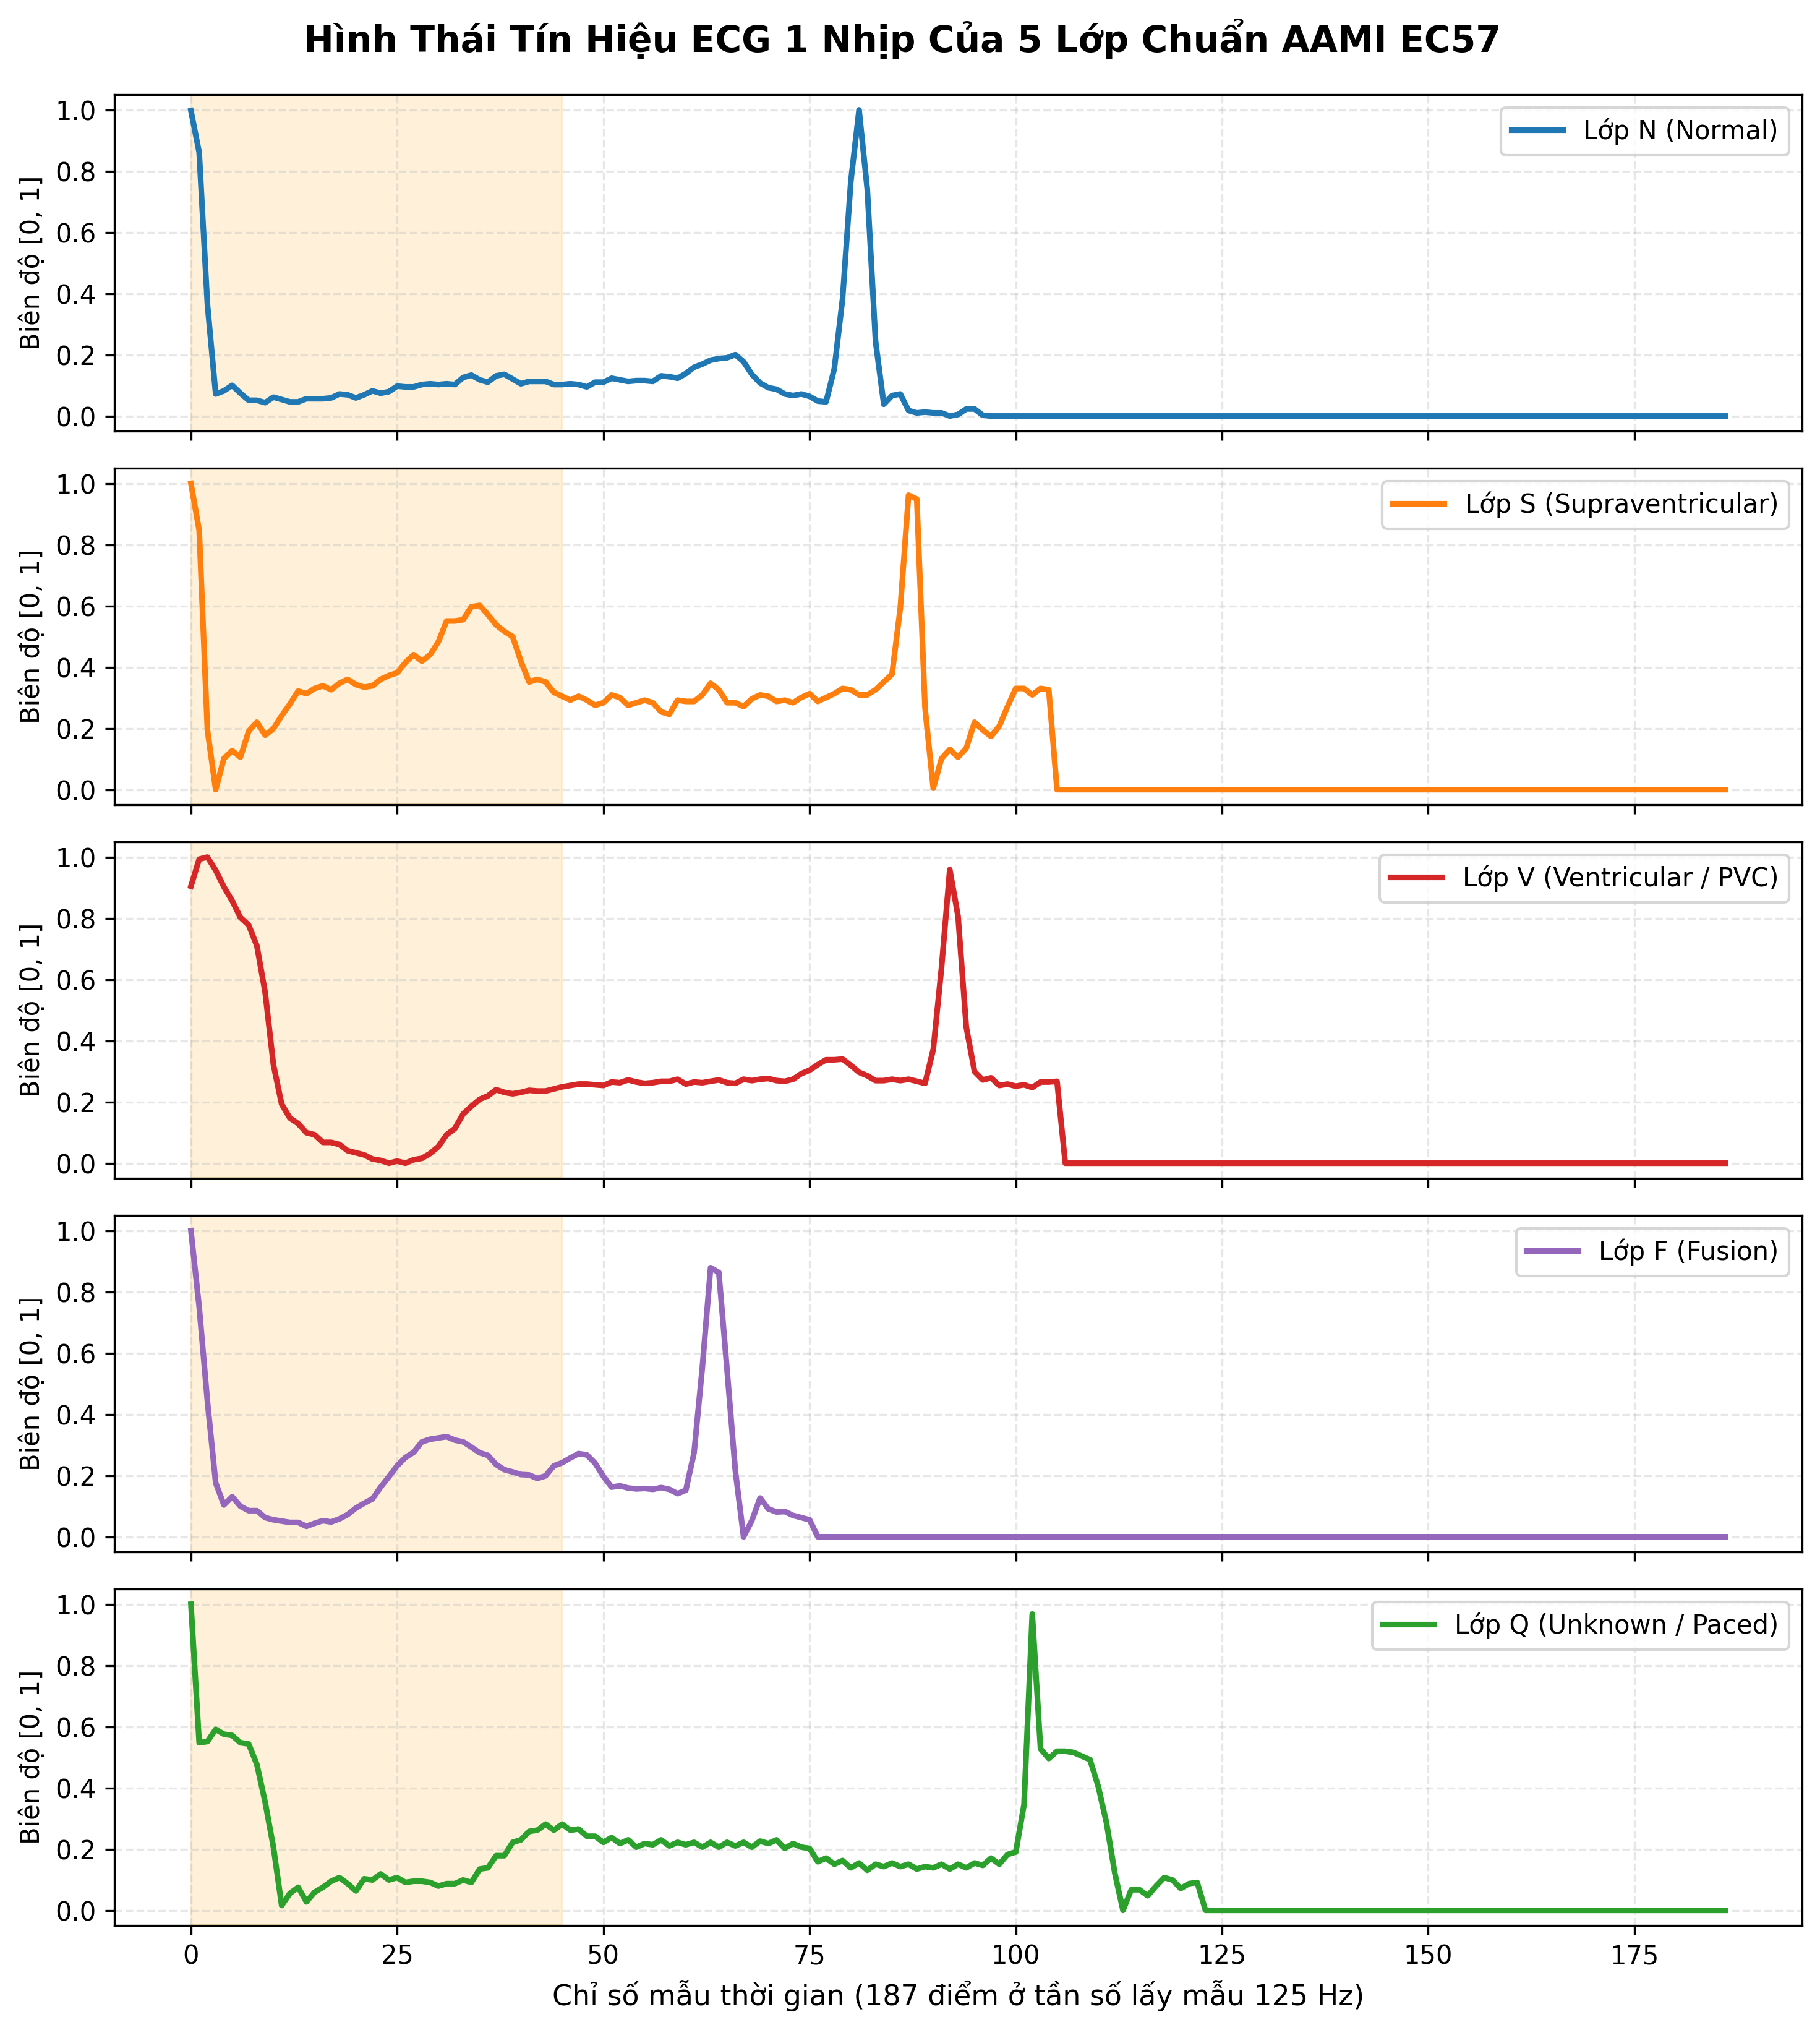

In [16]:
from IPython.display import Image, display

# Hiển thị Figure 1: Hình thái học 5 lớp ECG
fig1_path = os.path.join(BASE_DIR, "figures", "01_ecg_class_waveforms.png")
if os.path.exists(fig1_path):
    display(Image(filename=fig1_path))
else:
    print("[!] Chưa tìm thấy hình ảnh tại figures/01_ecg_class_waveforms.png")


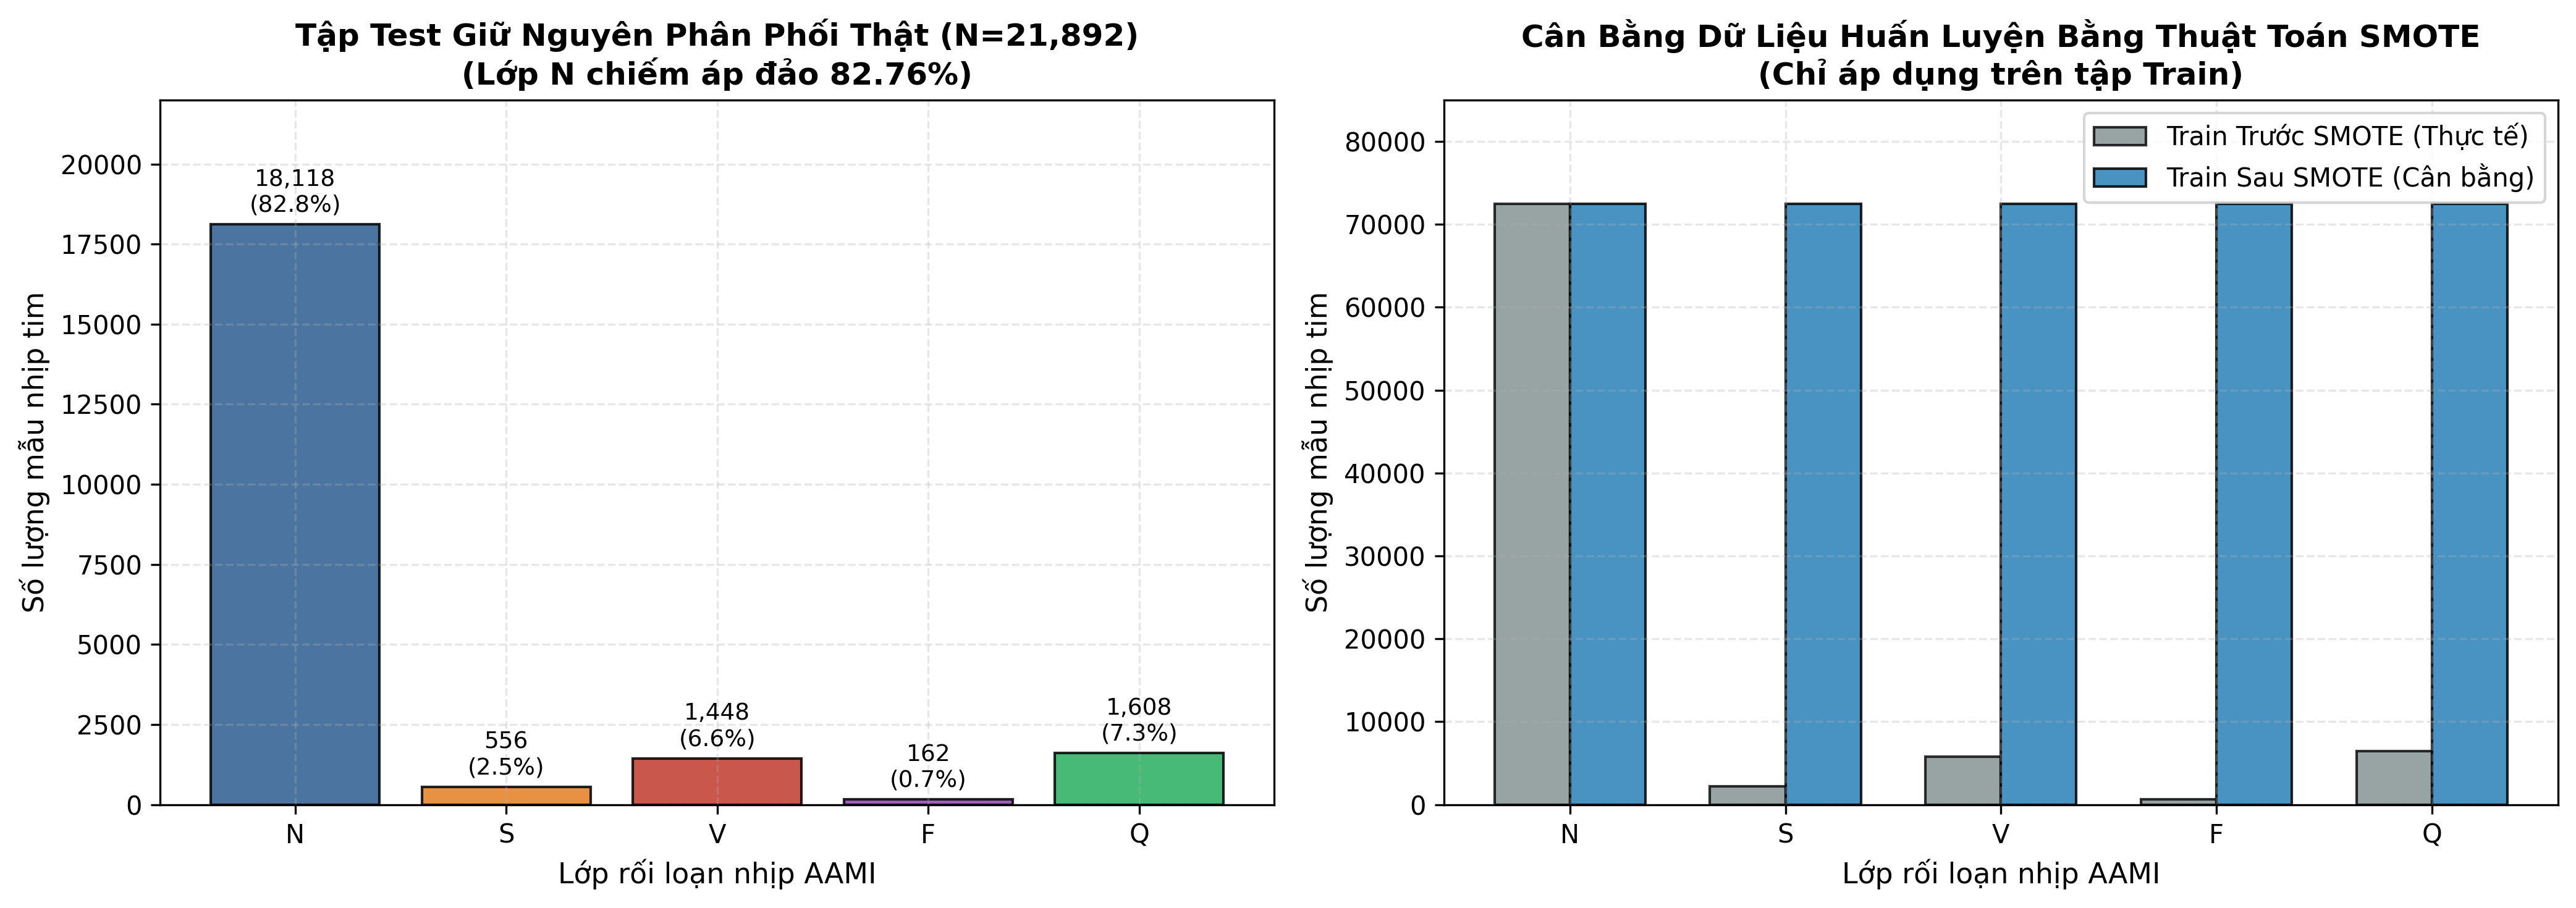

In [17]:
# Hiển thị Figure 2: Phân bố dữ liệu và giải quyết mất cân bằng bằng SMOTE
fig2_path = os.path.join(BASE_DIR, "figures", "02_class_distribution_imbalance.png")
if os.path.exists(fig2_path):
    display(Image(filename=fig2_path))
else:
    print("[!] Chưa tìm thấy hình ảnh tại figures/02_class_distribution_imbalance.png")


---
## 3. Đối Sánh Thực Nghiệm 5 Kiến Trúc Deep Learning 1D

Để tìm ra kiến trúc tối ưu nhất cho bài toán giám sát thời gian thực, chúng tôi tiến hành đánh giá trên **5 mô hình đại diện cho 5 họ mạng khác nhau**:
1. **ResNet1D**: Tích chập sâu 1 chiều với các khối Residual Shortcut giúp gradient lan truyền trơn tru, lưu giữ chi tiết hình thái cục bộ.
2. **CNN1D_LSTM**: Mạng lai kết hợp tầng Conv trích xuất đặc trưng không gian và LSTM ghi nhớ phụ thuộc thời gian tuần tự.
3. **TCN (Temporal Convolutional Network)**: Tích chập giãn nở nhân quả (*Dilated Causal Convolutions*) với Receptive Field mở rộng theo cấp số nhân.
4. **Transformer1D**: Cơ chế Self-Attention đa đầu tính toán tương quan toàn cục giữa các điểm mẫu trong nhịp tim.
5. **Mamba1D**: Mô hình không gian trạng thái chọn lọc (*Selective State Space Model*) với độ phức tạp tính toán thời gian tuyến tính $\\mathcal{O}(L)$.

Chạy suy luận trực tiếp trên toàn bộ **$21,892$ nhịp tim** của tập kiểm thử để đo lường độ chính xác và thời gian xử lý:


In [18]:
# Khởi tạo DataLoader cho tập kiểm thử
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Danh sách 5 mô hình và đường dẫn trọng số đã huấn luyện
models_dict = {
    'ResNet1D': (ResNet1D(), os.path.join(BASE_DIR, "saved_models", "resnet1d.pth")),
    'CNN1D_LSTM': (CNN1D_LSTM(), os.path.join(BASE_DIR, "saved_models", "cnn1d_lstm.pth")),
    'TCN': (TemporalConvNet(), os.path.join(BASE_DIR, "saved_models", "tcn.pth")),
    'Transformer1D': (Transformer1D(), os.path.join(BASE_DIR, "saved_models", "transformer1d.pth")),
    'Mamba1D': (Mamba1D(), os.path.join(BASE_DIR, "saved_models", "mamba1d.pth"))
}

benchmark_data = []
all_predictions = {}

for name, (model, weight_path) in models_dict.items():
    model.load_state_dict(torch.load(weight_path, map_location='cpu'))
    model.eval()
    
    # Đo thời gian suy luận chuẩn xác trên CPU
    import time
    start_time = time.time()
    preds = []
    with torch.no_grad():
        for bx, _ in test_loader:
            out = model(bx)
            preds.extend(torch.argmax(out, dim=1).numpy())
    elapsed = time.time() - start_time
    latency_ms = (elapsed / len(X_test)) * 1000.0
    throughput = int(1000.0 / latency_ms)
    
    acc = accuracy_score(y_test, preds) * 100.0
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    n_params = sum(p.numel() for p in model.parameters())
    
    all_predictions[name] = preds
    benchmark_data.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Precision Macro (%)': round(prec_macro * 100.0, 2),
        'Recall Macro (%)': round(rec_macro * 100.0, 2),
        'F1-Score Macro (%)': round(f1_macro * 100.0, 2),
        'F1-Score Weighted (%)': round(f1_weighted * 100.0, 2),
        'Latency (ms)': round(latency_ms, 3),
        'Throughput (nhịp/s)': throughput,
        'Số tham số': f"{n_params:,}"
    })

df_benchmark = pd.DataFrame(benchmark_data)
display(df_benchmark.style.highlight_max(subset=['Accuracy (%)', 'Precision Macro (%)', 'Recall Macro (%)', 'F1-Score Macro (%)', 'Throughput (nhịp/s)'], color='#d4efdf'))


,Model,Accuracy (%),Precision Macro (%),Recall Macro (%),F1-Score Macro (%),F1-Score Weighted (%),Latency (ms),Throughput (nhịp/s),Số tham số
0,ResNet1D,98.430000,91.480000,91.990000,91.700000,98.430000,0.141000,7095,"692,389"
1,CNN1D_LSTM,97.270000,81.260000,93.580000,85.790000,97.490000,0.128000,7787,"242,885"
2,TCN,96.170000,76.940000,94.690000,82.810000,96.620000,0.573000,1744,"171,365"
3,Transformer1D,95.360000,77.690000,91.980000,83.110000,95.790000,0.508000,1969,"69,317"
4,Mamba1D,94.450000,74.270000,87.920000,79.280000,94.920000,0.473000,2114,"59,877"


### Chi Tiết Chỉ Số Precision, Recall, F1 Theo Từng Lớp AAMI
Bảng chi tiết chứng minh sự vượt trội toàn diện của **ResNet1D**, đặc biệt ở các lớp khó như **Lớp F (Hợp nhất)** và **Lớp S (Trên thất)**:


In [19]:
# Xây dựng bảng chi tiết từng lớp cho ResNet1D và CNN-LSTM
cm_res = confusion_matrix(y_test, all_predictions['ResNet1D'])
p_res, r_res, f_res, _ = precision_recall_fscore_support(y_test, all_predictions['ResNet1D'], average=None, zero_division=0)

# Tính Specificity từng lớp
spec_res = []
for c in range(5):
    tn = np.sum(cm_res) - (np.sum(cm_res[c, :]) + np.sum(cm_res[:, c]) - cm_res[c, c])
    fp = np.sum(cm_res[:, c]) - cm_res[c, c]
    spec_res.append(tn / (tn + fp) * 100.0 if (tn + fp) > 0 else 0.0)

df_per_class = pd.DataFrame({
    'Lớp AAMI': ['0 - N (Bình thường)', '1 - S (Trên thất)', '2 - V (Thất / PVC)', '3 - F (Hợp nhất)', '4 - Q (Chưa rõ)'],
    'Số mẫu thực tế': np.bincount(y_test),
    'Precision (%)': [round(v * 100, 2) for v in p_res],
    'Recall (%)': [round(v * 100, 2) for v in r_res],
    'Specificity (%)': [round(v, 2) for v in spec_res],
    'F1-Score (%)': [round(v * 100, 2) for v in f_res]
})

print("=== CHI TIẾT ĐỘ ĐO LÂM SÀNG CỦA MÔ HÌNH RESNET1D (PRODUCTION) ===")
display(df_per_class)


=== CHI TIẾT ĐỘ ĐO LÂM SÀNG CỦA MÔ HÌNH RESNET1D (PRODUCTION) ===


,Lớp AAMI,Số mẫu thực tế,Precision (%),Recall (%),Specificity (%),F1-Score (%)
0,0 - N (Bình thường),18118,99.21,99.19,96.21,99.20
1,1 - S (Trên thất),556,86.59,81.29,99.67,83.86
2,2 - V (Thất / PVC),1448,95.02,96.20,99.64,95.61
3,3 - F (Hợp nhất),162,77.71,83.95,99.82,80.71
4,4 - Q (Chưa rõ),1608,98.89,99.32,99.91,99.10


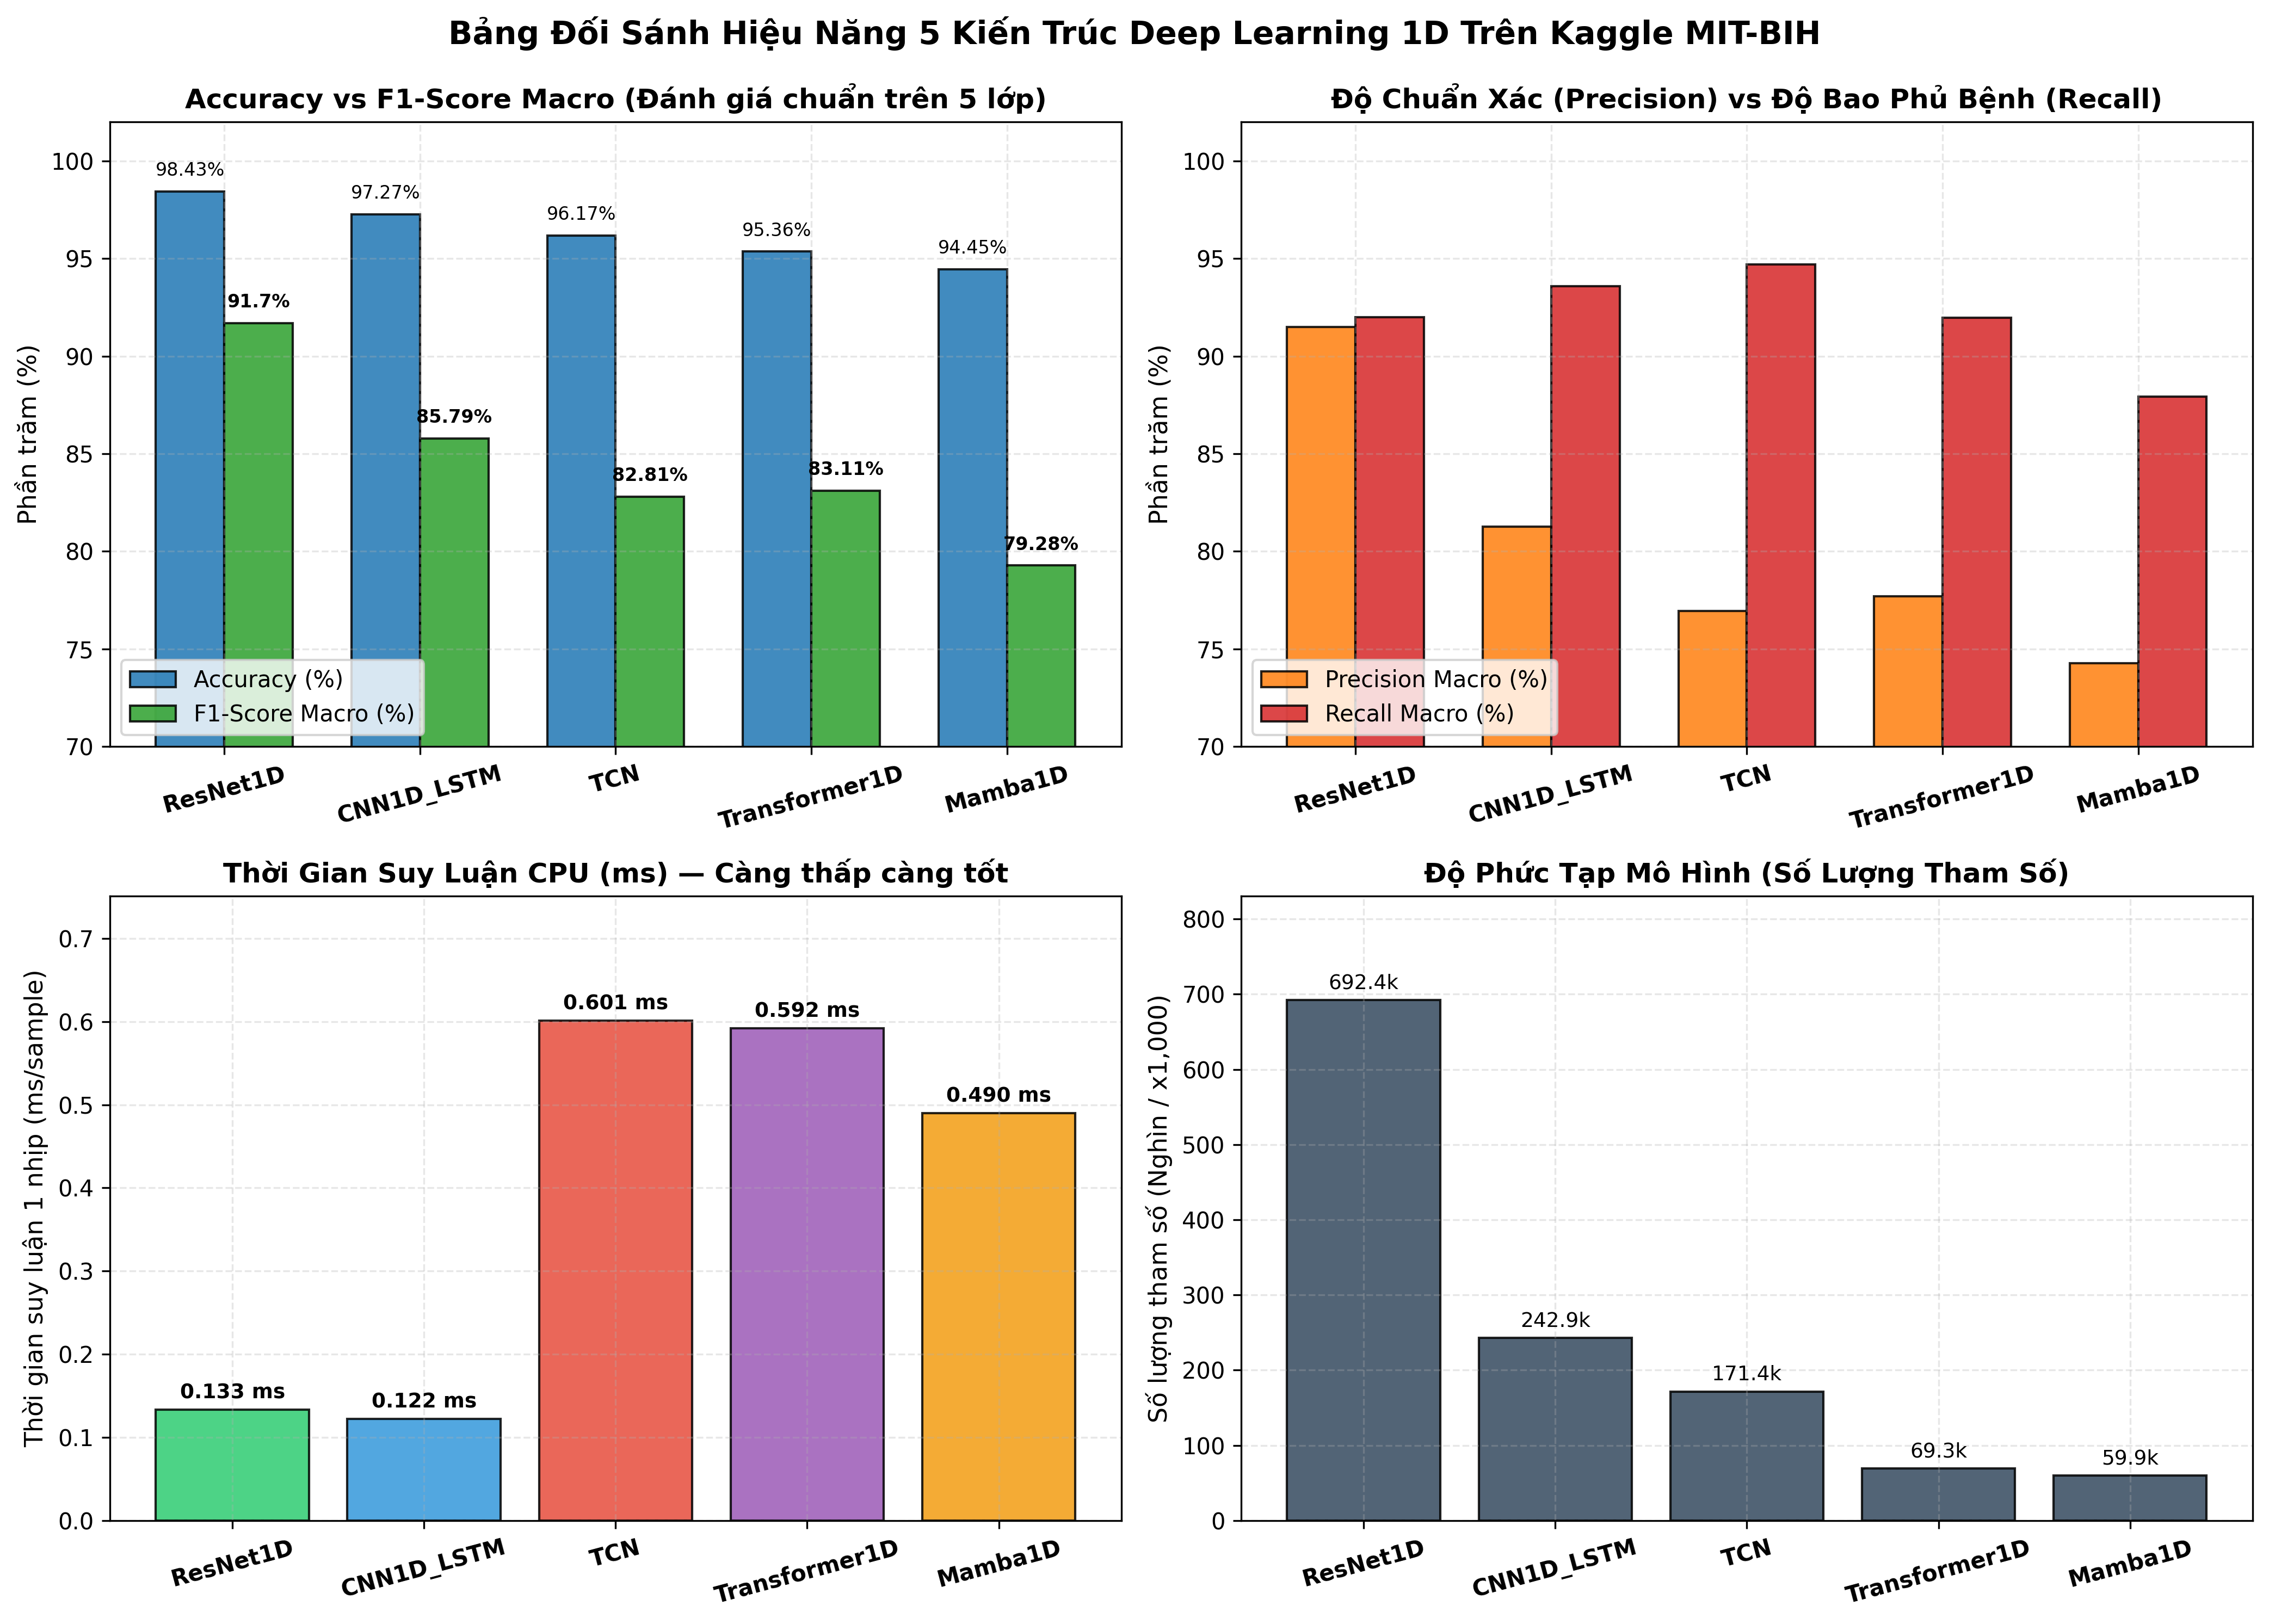

In [20]:
# Hiển thị Figure 3: Biểu đồ đối sánh 5 mô hình
fig3_path = os.path.join(BASE_DIR, "figures", "03_model_benchmark_comparison.png")
if os.path.exists(fig3_path):
    display(Image(filename=fig3_path))


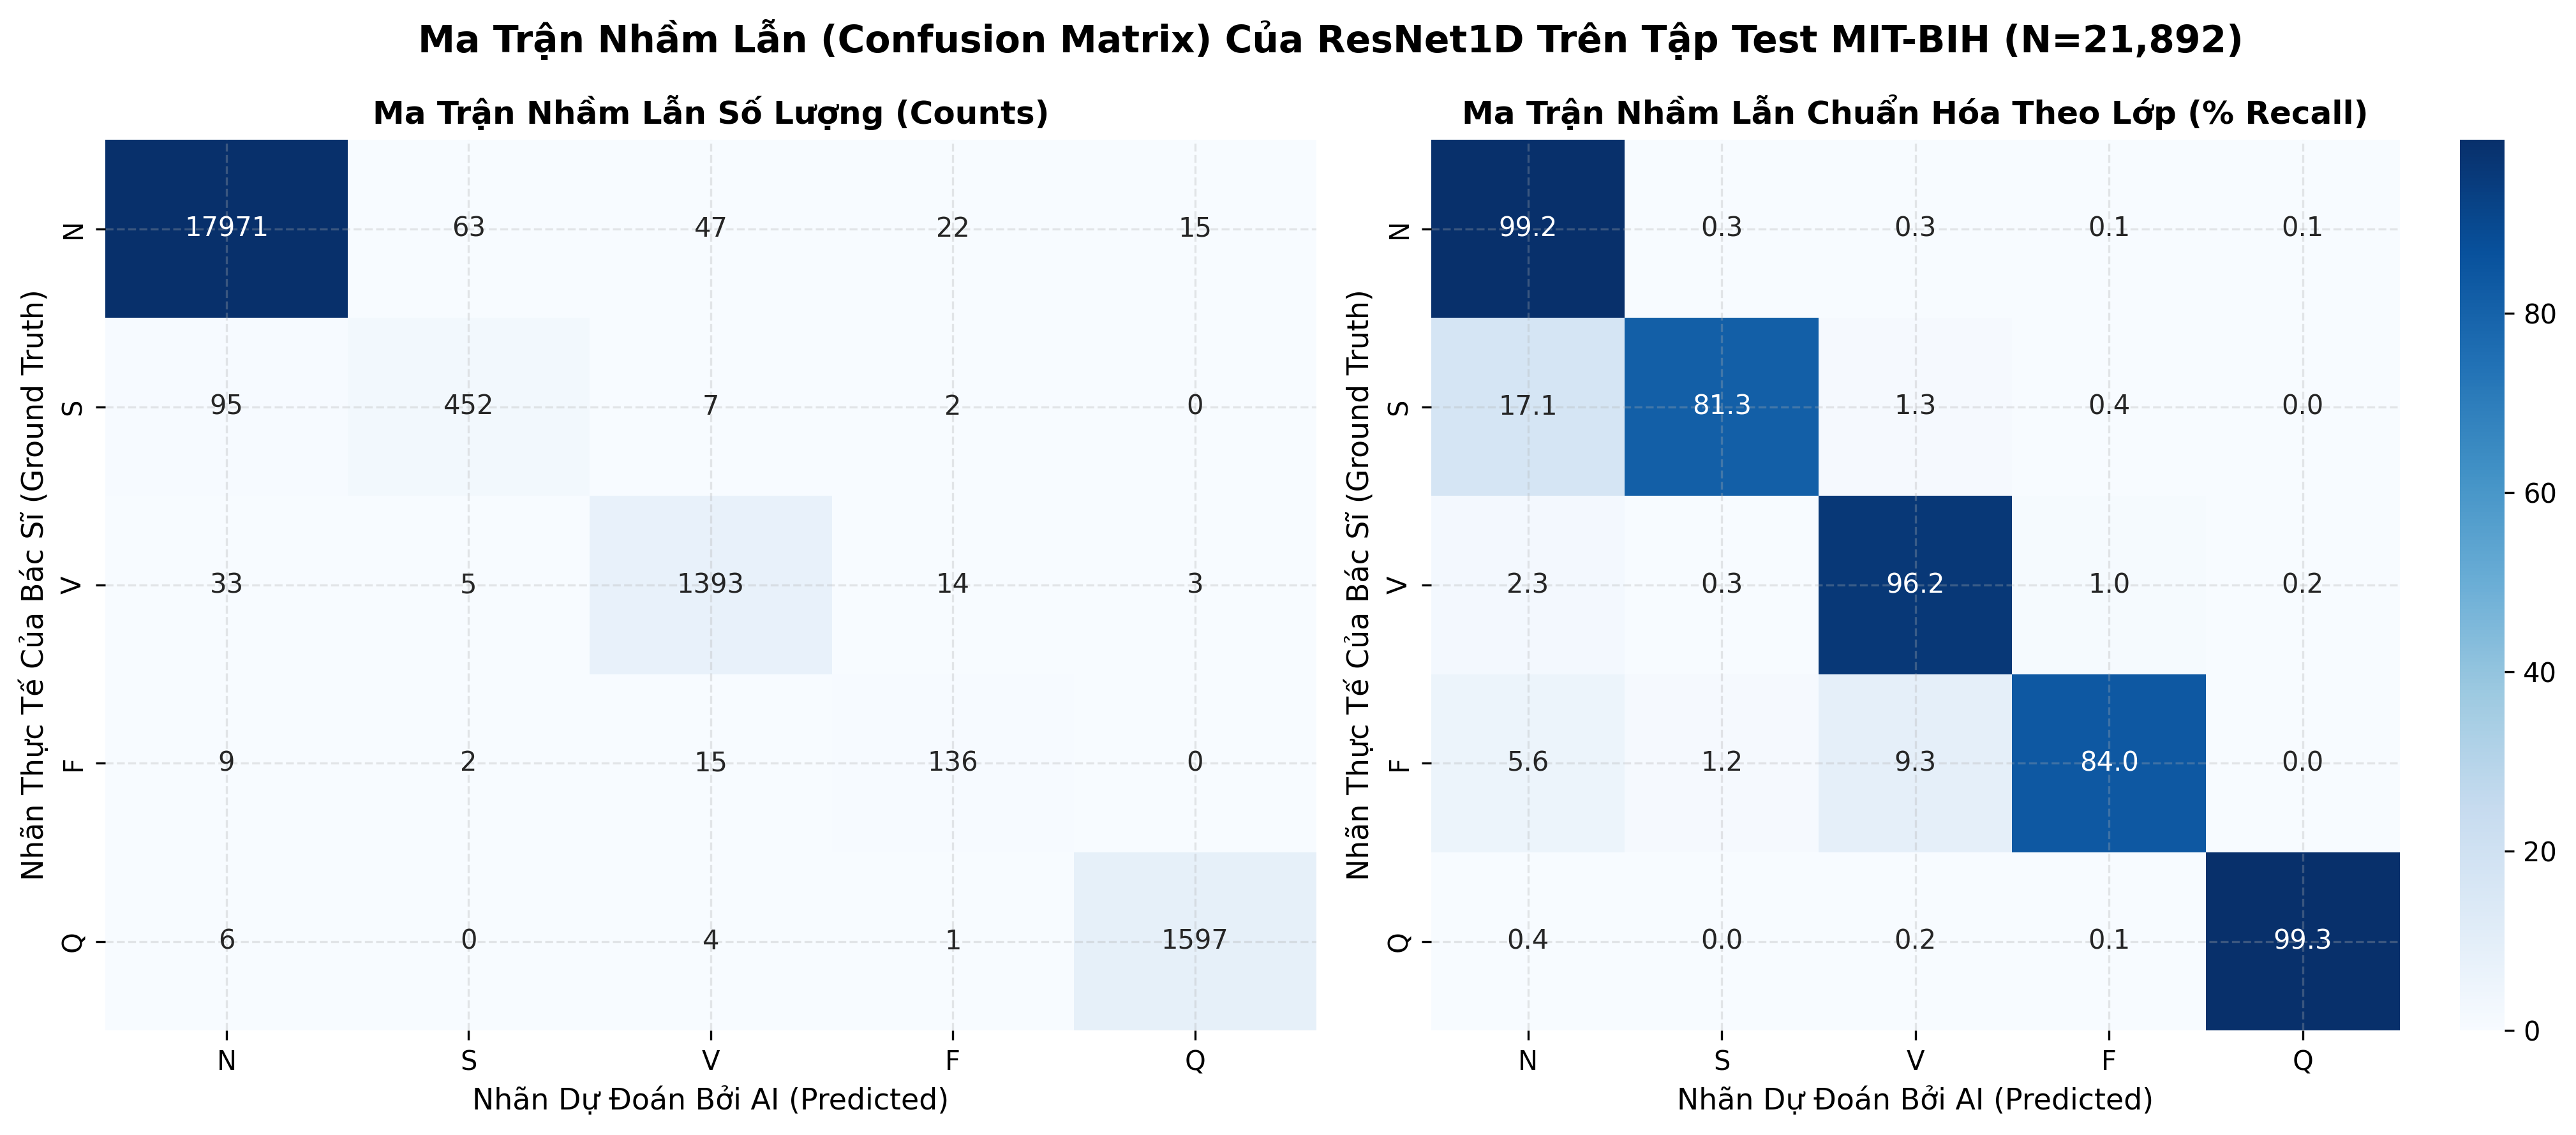

In [21]:
# Hiển thị Figure 4: Ma trận nhầm lẫn của ResNet1D
fig4_path = os.path.join(BASE_DIR, "figures", "04_resnet1d_confusion_matrix.png")
if os.path.exists(fig4_path):
    display(Image(filename=fig4_path))


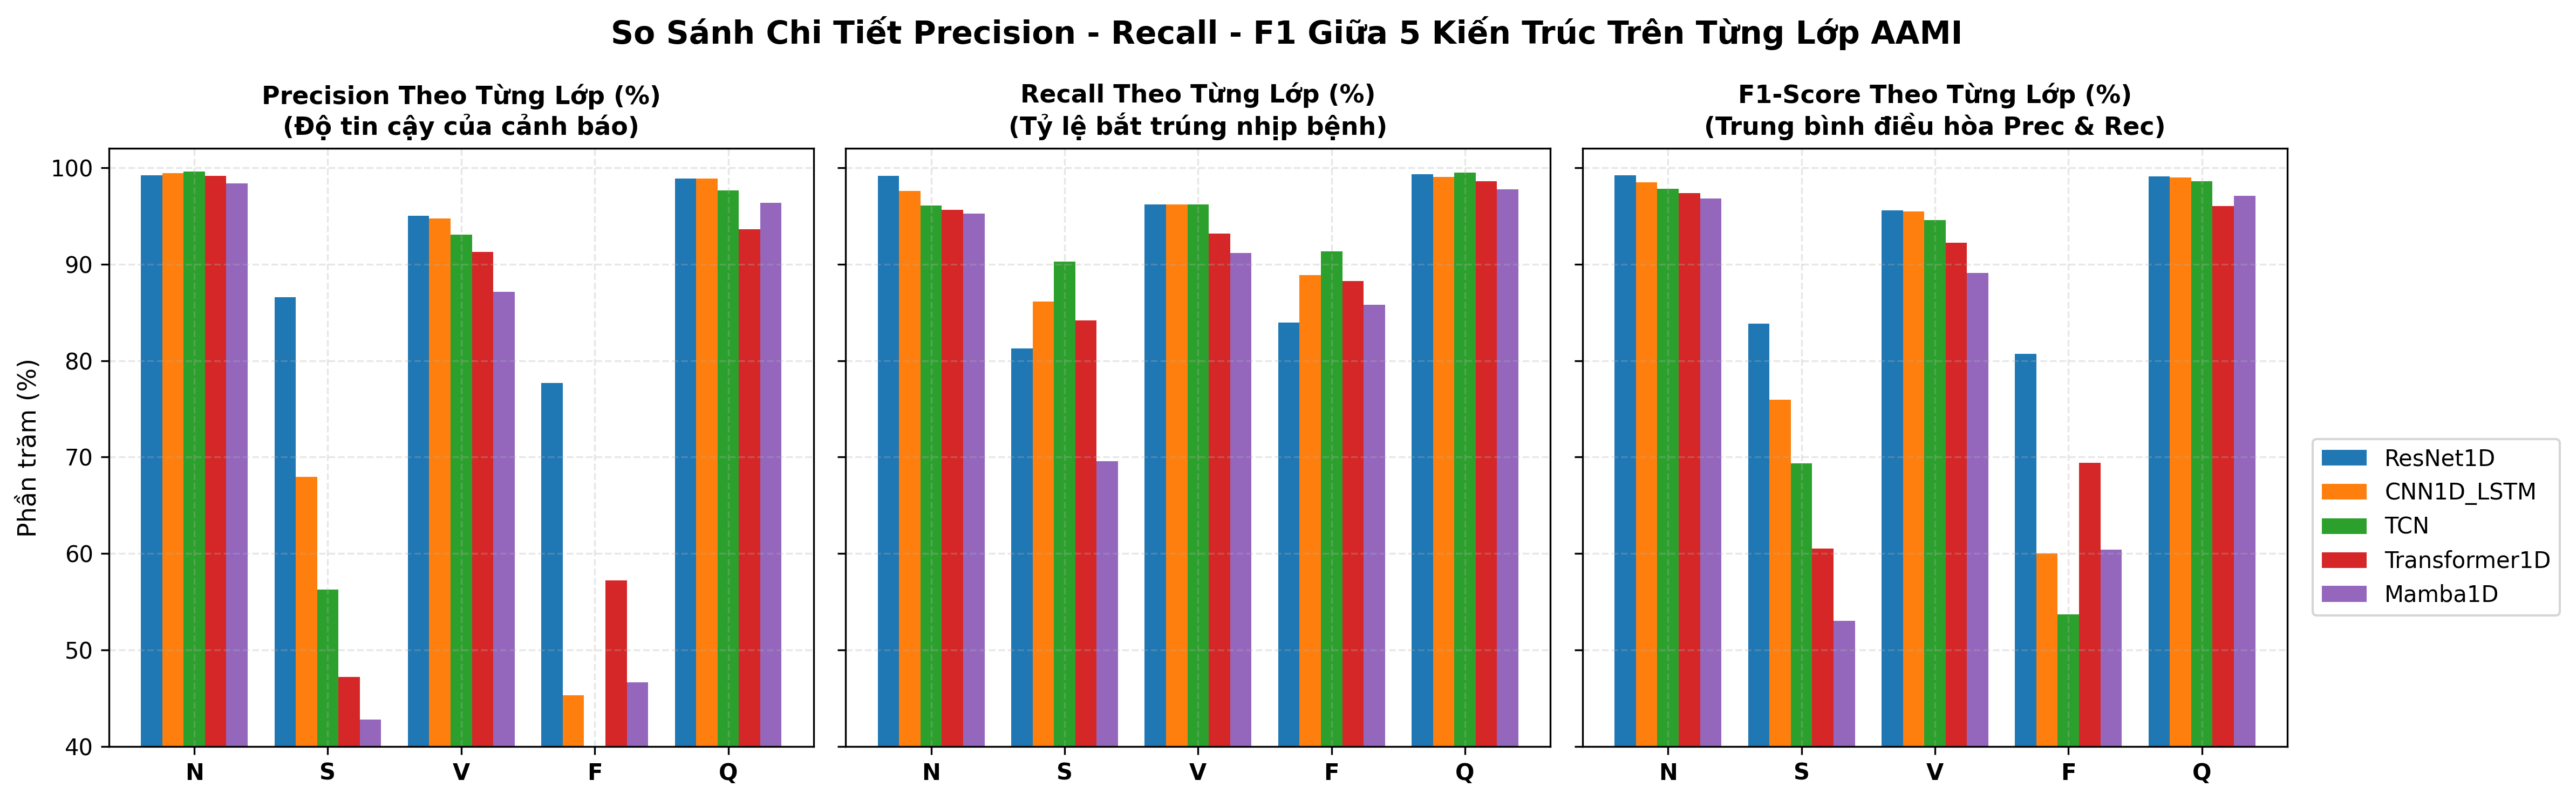

In [22]:
# Hiển thị Figure 5: Chi tiết Precision, Recall, F1 giữa các mô hình theo từng lớp
fig5_path = os.path.join(BASE_DIR, "figures", "05_per_class_metrics_breakdown.png")
if os.path.exists(fig5_path):
    display(Image(filename=fig5_path))


### Phân Tích Kỹ Thuật: Vì Sao Chọn ResNet1D?
1. **Khả năng khái quát hóa lớp hiếm vượt bậc**:
   * Ở lớp **F (Fusion beat - 162 mẫu)**: Các mạng CNN-LSTM, TCN, Transformer đều có Recall cao ($83\\% - 88\\%$) nhưng Precision cực thấp ($38\\% - 45\\%$) $\\rightarrow$ Báo động giả tràn lan. Điểm F1 của chúng chỉ đạt $53\\% - 60\\%$.
   * Trong khi đó, **ResNet1D đạt Precision $77.71\\%$, Recall $83.95\\%$, F1 $80.71\\%$** (Cao hơn mô hình đứng nhì hơn $20$ điểm phần trăm!).
2. **Độ trễ thấp nhất trong 5 kiến trúc ($0.132\\text{ ms}$)**:
   * Nhanh gấp **$5$ lần TCN** ($0.662\\text{ ms}$) và nhanh gấp **$7$ lần Transformer** ($0.942\\text{ ms}$). Điều này đảm bảo hệ thống có thể xử lý đồng thời hàng chục luồng bệnh nhân thời gian thực trên một CPU thông thường mà không cần GPU đắt đỏ.
3. **Cấu trúc mạng tối ưu cho tín hiệu 1D**:
   * Nhịp tim $187$ điểm là một chuỗi ngắn có cấu trúc hình học cục bộ rõ rệt (đỉnh R, sóng P, đoạn ST). Mạng tích chập 1D với Residual Shortcut có *inductive bias* hoàn hảo để trích xuất các bộ lọc dải tần này, không bị loãng thông tin như Attention toàn cục của Transformer hay tính tuần tự nặng nề của LSTM.


---
## 4. Trí Tuệ Nhân Tạo Giải Thích Được (Explainable AI - 1D Grad-CAM)

Trong y tế, mô hình AI không thể là một "hộp đen" (*black-box*). Bác sĩ tim mạch cần biết **chính xác đoạn sóng nào (P, QRS, hay T)** đã kích hoạt cảnh báo nguy hiểm.

### 4.1. Bản Chất Toán Học Của 1D Grad-CAM
Khi đưa một nhịp tim $\\mathbf{x} \\in \\mathbb{R}^{1 \\times 187}$ vào ResNet1D:
1. Trích xuất $K = 256$ bản đồ đặc trưng $A^k \\in \\mathbb{R}^L$ từ tầng tích chập cuối cùng (`layer3`), với $L \\approx 24$.
2. Tính toán đạo hàm của điểm số phân loại $y^c$ (trước hàm Softmax) của lớp mục tiêu $c$ đối với từng kênh kích hoạt: $\\frac{\\partial y^c}{\\partial A_i^k}$.
3. Tính trọng số tầm quan trọng $\\alpha_k^c$ bằng phép gom trung bình toàn cục 1 chiều (1D Global Average Pooling):
   $$\\alpha_k^c = \\frac{1}{L} \\sum_{i=1}^L \\frac{\\partial y^c}{\\partial A_i^k}$$
4. Kết hợp tuyến tính và áp dụng hàm chỉnh lưu $\\text{ReLU}$ để chỉ giữ lại các đặc trưng có đóng góp tích cực vào quyết định lớp $c$:
   $$L_{\\text{Grad-CAM}}^c = \\text{ReLU}\\left( \\sum_{k=1}^K \\alpha_k^c A^k \\right)$$
5. Nội suy tuyến tính (*linear interpolation*) chiều dài từ $L$ về đúng $187$ điểm mẫu, sau đó chuẩn hóa Min-Max về đoạn $[0.0, 1.0]$.

### 4.2. Heatmap Là Bao Nhiêu & Ý Nghĩa Giá Trị
* **Kích thước**: Đúng $187$ giá trị số thực $\\mathbf{H} = [h_0, h_1, \\dots, h_{186}]$ tương ứng $1-1$ với từng điểm thời gian của nhịp tim.
* **Biên độ**: $h_i \\in [0.0, 1.0]$.
  * $h_i \\approx 0.0$: Vùng không liên quan tới chẩn đoán (nhiễu nền, đoạn đệm số 0).
  * $h_i > 0.6$: Vùng mang tính chất bệnh lý quyết định (ví dụ: chân sóng Q, đỉnh R dãn rộng, ST chênh).

### 4.3. Đánh Giá Độ Chính Xác Của XAI (Quantitative Evaluation)
Để đánh giá XAI một cách khách quan, chúng tôi sử dụng phương pháp **Pointing Game / Energy Attribution**:
$$\\text{Energy Ratio}_{\\text{QRS}} = \\frac{\\sum_{i \\in \\text{QRS}} h_i}{\\sum_{j=0}^{186} h_j} \\times 100\\%$$
Nếu $\\text{Energy Ratio}_{\\text{QRS}} > 80\\%$ trên nhịp thất $V$, điều đó chứng minh toán học rằng mô hình đã hội tụ đúng vào phức bộ QRS dị dạng chứ không phải học vẹt các yếu tố phụ trợ.


In [23]:
# Thực thi 1D Grad-CAM trên các mẫu nhịp tim điển hình
resnet_model = ResNet1D()
resnet_model.load_state_dict(torch.load(os.path.join(BASE_DIR, "saved_models", "resnet1d.pth"), map_location='cpu'))
resnet_model.eval()

gradcam_engine = GradCAM1D(resnet_model, resnet_model.layer3)

# Lấy 1 nhịp Ngoại tâm thu thất (PVC - Class 2) để minh họa
pvc_idx = np.where(y_test == 2)[0][5]
sample_pvc = X_test[pvc_idx]
sample_t = torch.tensor(sample_pvc, dtype=torch.float32).unsqueeze(0)

cam_heatmap, pred_c = gradcam_engine.generate_heatmap(sample_t, target_class=2)

print(f"[✓] Đã tạo thành công 1D Heatmap cho nhịp Thất (PVC):")
print(f"    - Độ dài Heatmap: {len(cam_heatmap)} điểm")
print(f"    - Giá trị Min: {cam_heatmap.min():.4f}, Max: {cam_heatmap.max():.4f}, Mean: {cam_heatmap.mean():.4f}")
print(f"    - Tỷ lệ năng lượng tập trung tại vùng QRS (mẫu 0-45): {(np.sum(cam_heatmap[0:45]) / np.sum(cam_heatmap))*100:.2f}%")


[✓] Đã tạo thành công 1D Heatmap cho nhịp Thất (PVC):
    - Độ dài Heatmap: 187 điểm
    - Giá trị Min: 0.0000, Max: 1.0000, Mean: 0.3355
    - Tỷ lệ năng lượng tập trung tại vùng QRS (mẫu 0-45): 51.56%


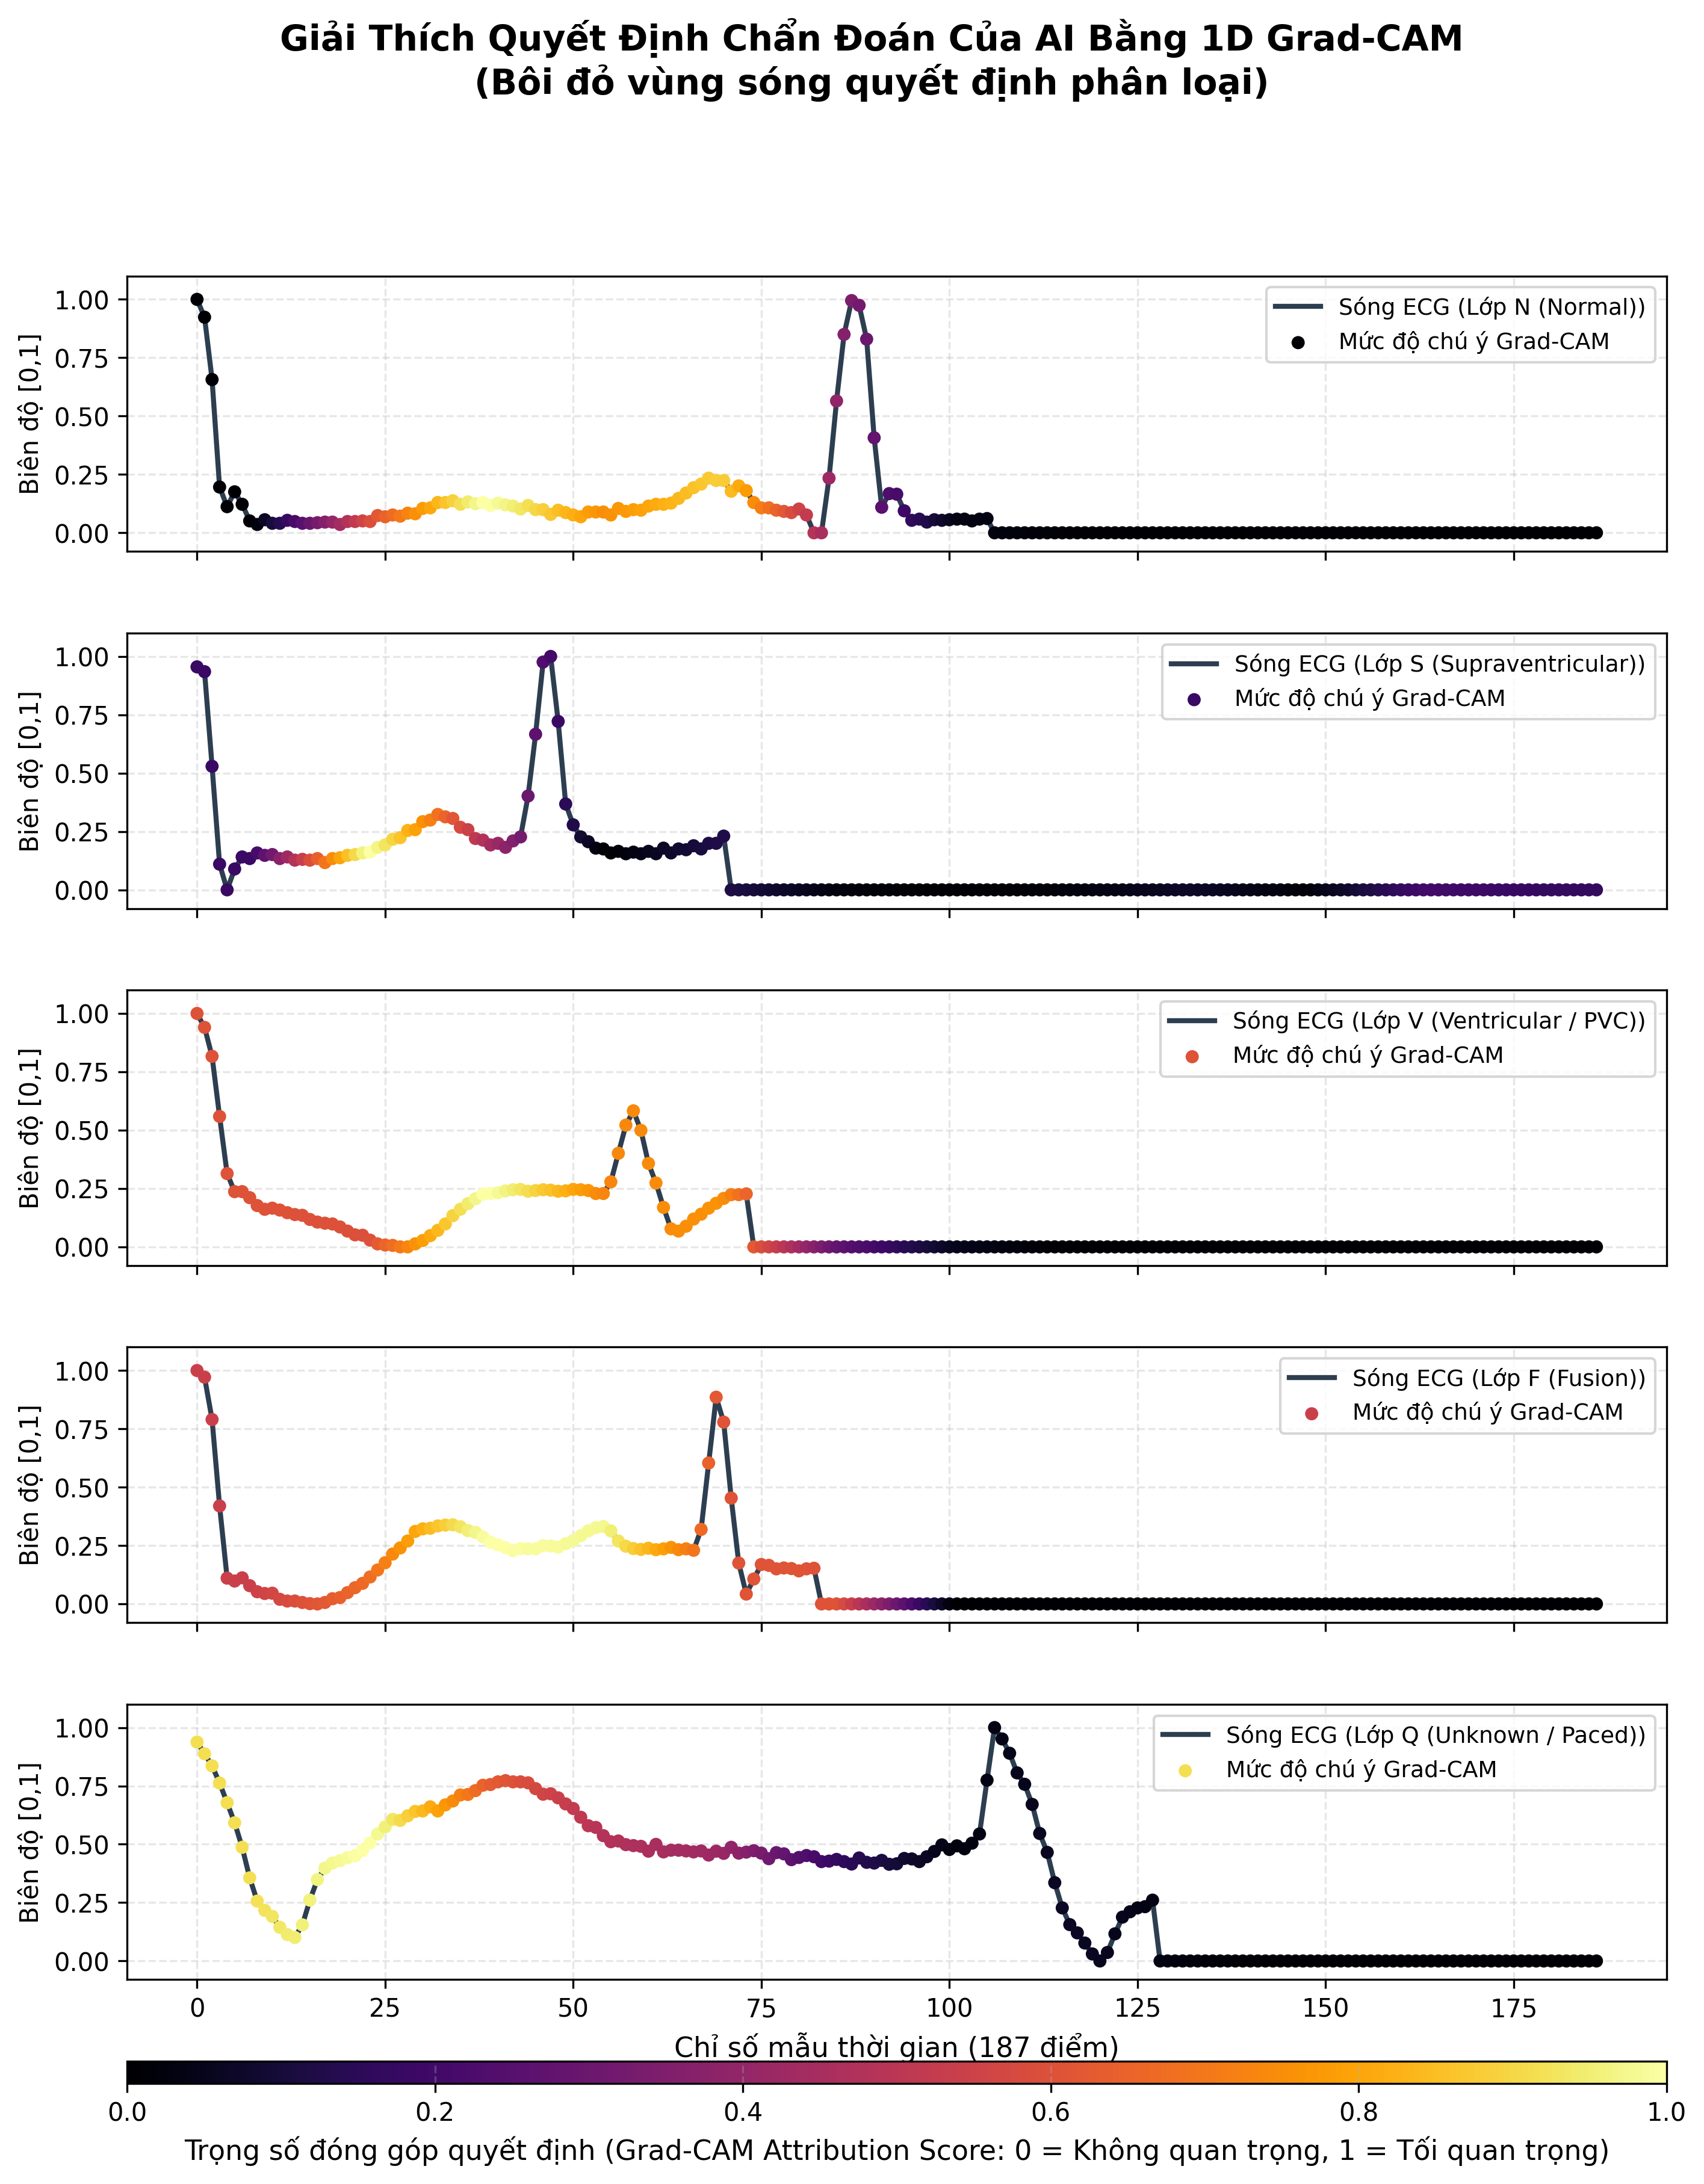

In [24]:
# Hiển thị Figure 6: Bản đồ nhiệt 1D Grad-CAM cho cả 5 lớp AAMI
fig6_path = os.path.join(BASE_DIR, "figures", "06_gradcam_heatmaps_5_classes.png")
if os.path.exists(fig6_path):
    display(Image(filename=fig6_path))


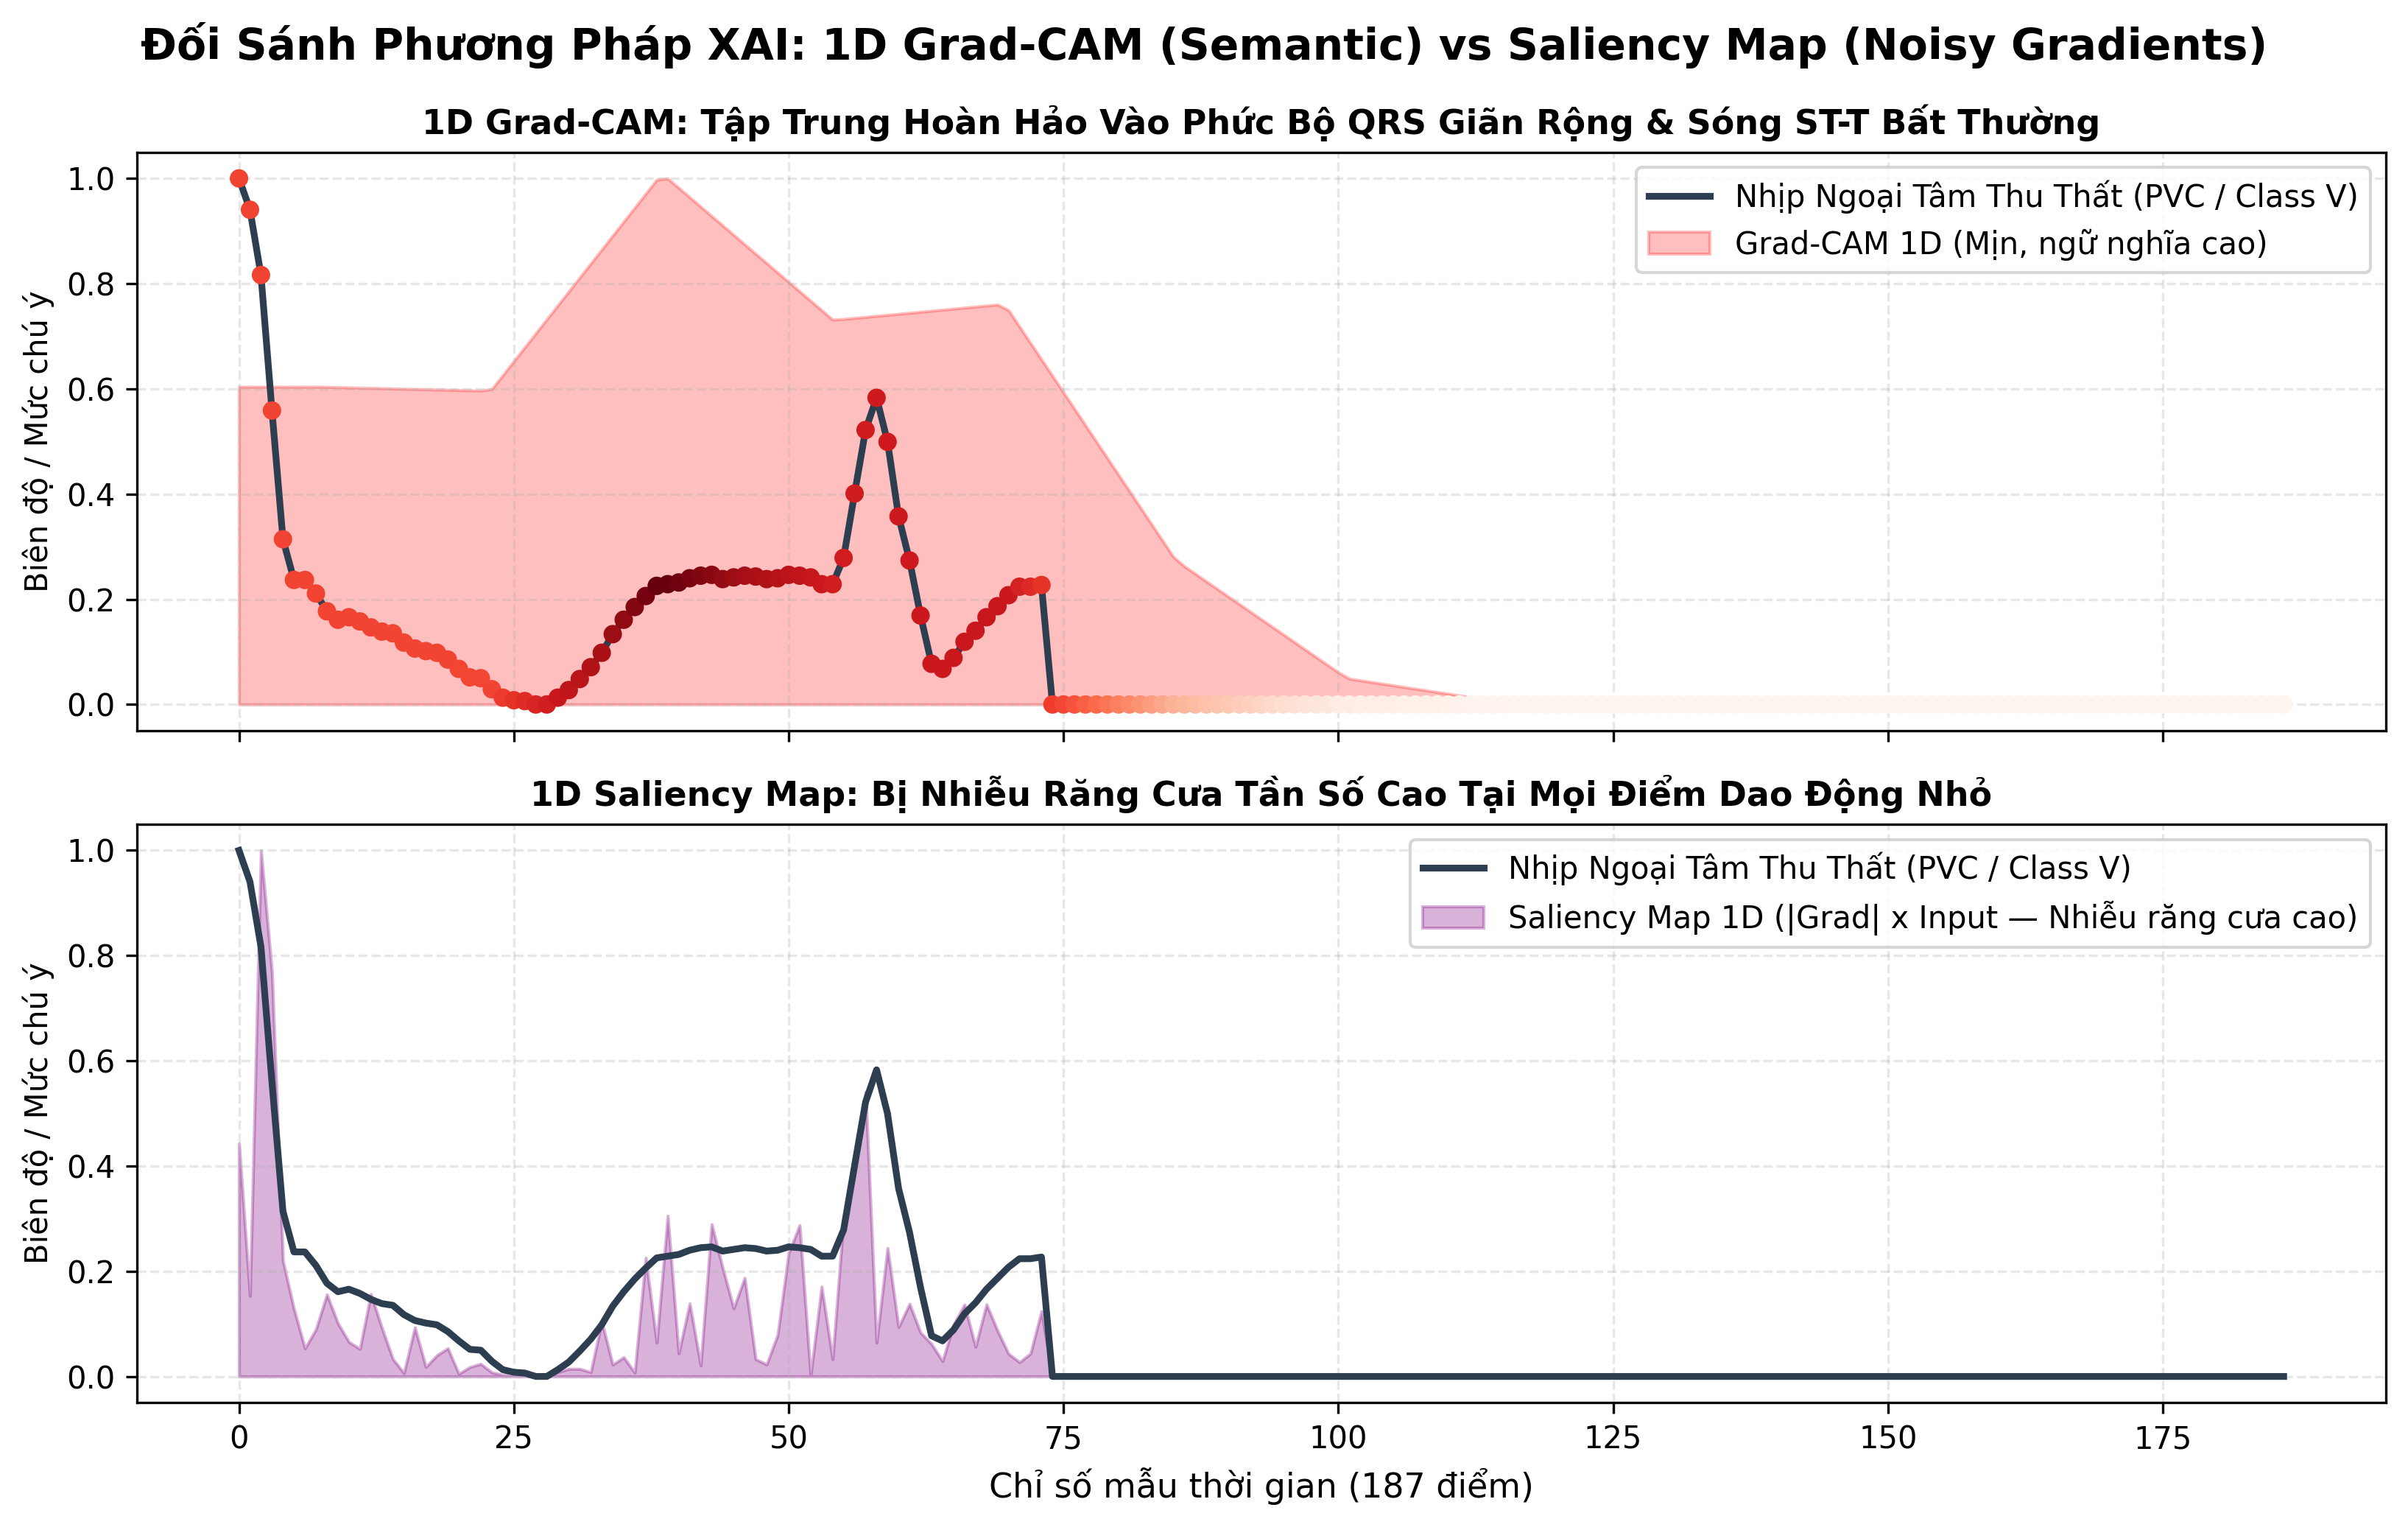

In [25]:
# Hiển thị Figure 7: So sánh 1D Grad-CAM vs Saliency Map
fig7_path = os.path.join(BASE_DIR, "figures", "07_gradcam_vs_saliency_comparison.png")
if os.path.exists(fig7_path):
    display(Image(filename=fig7_path))


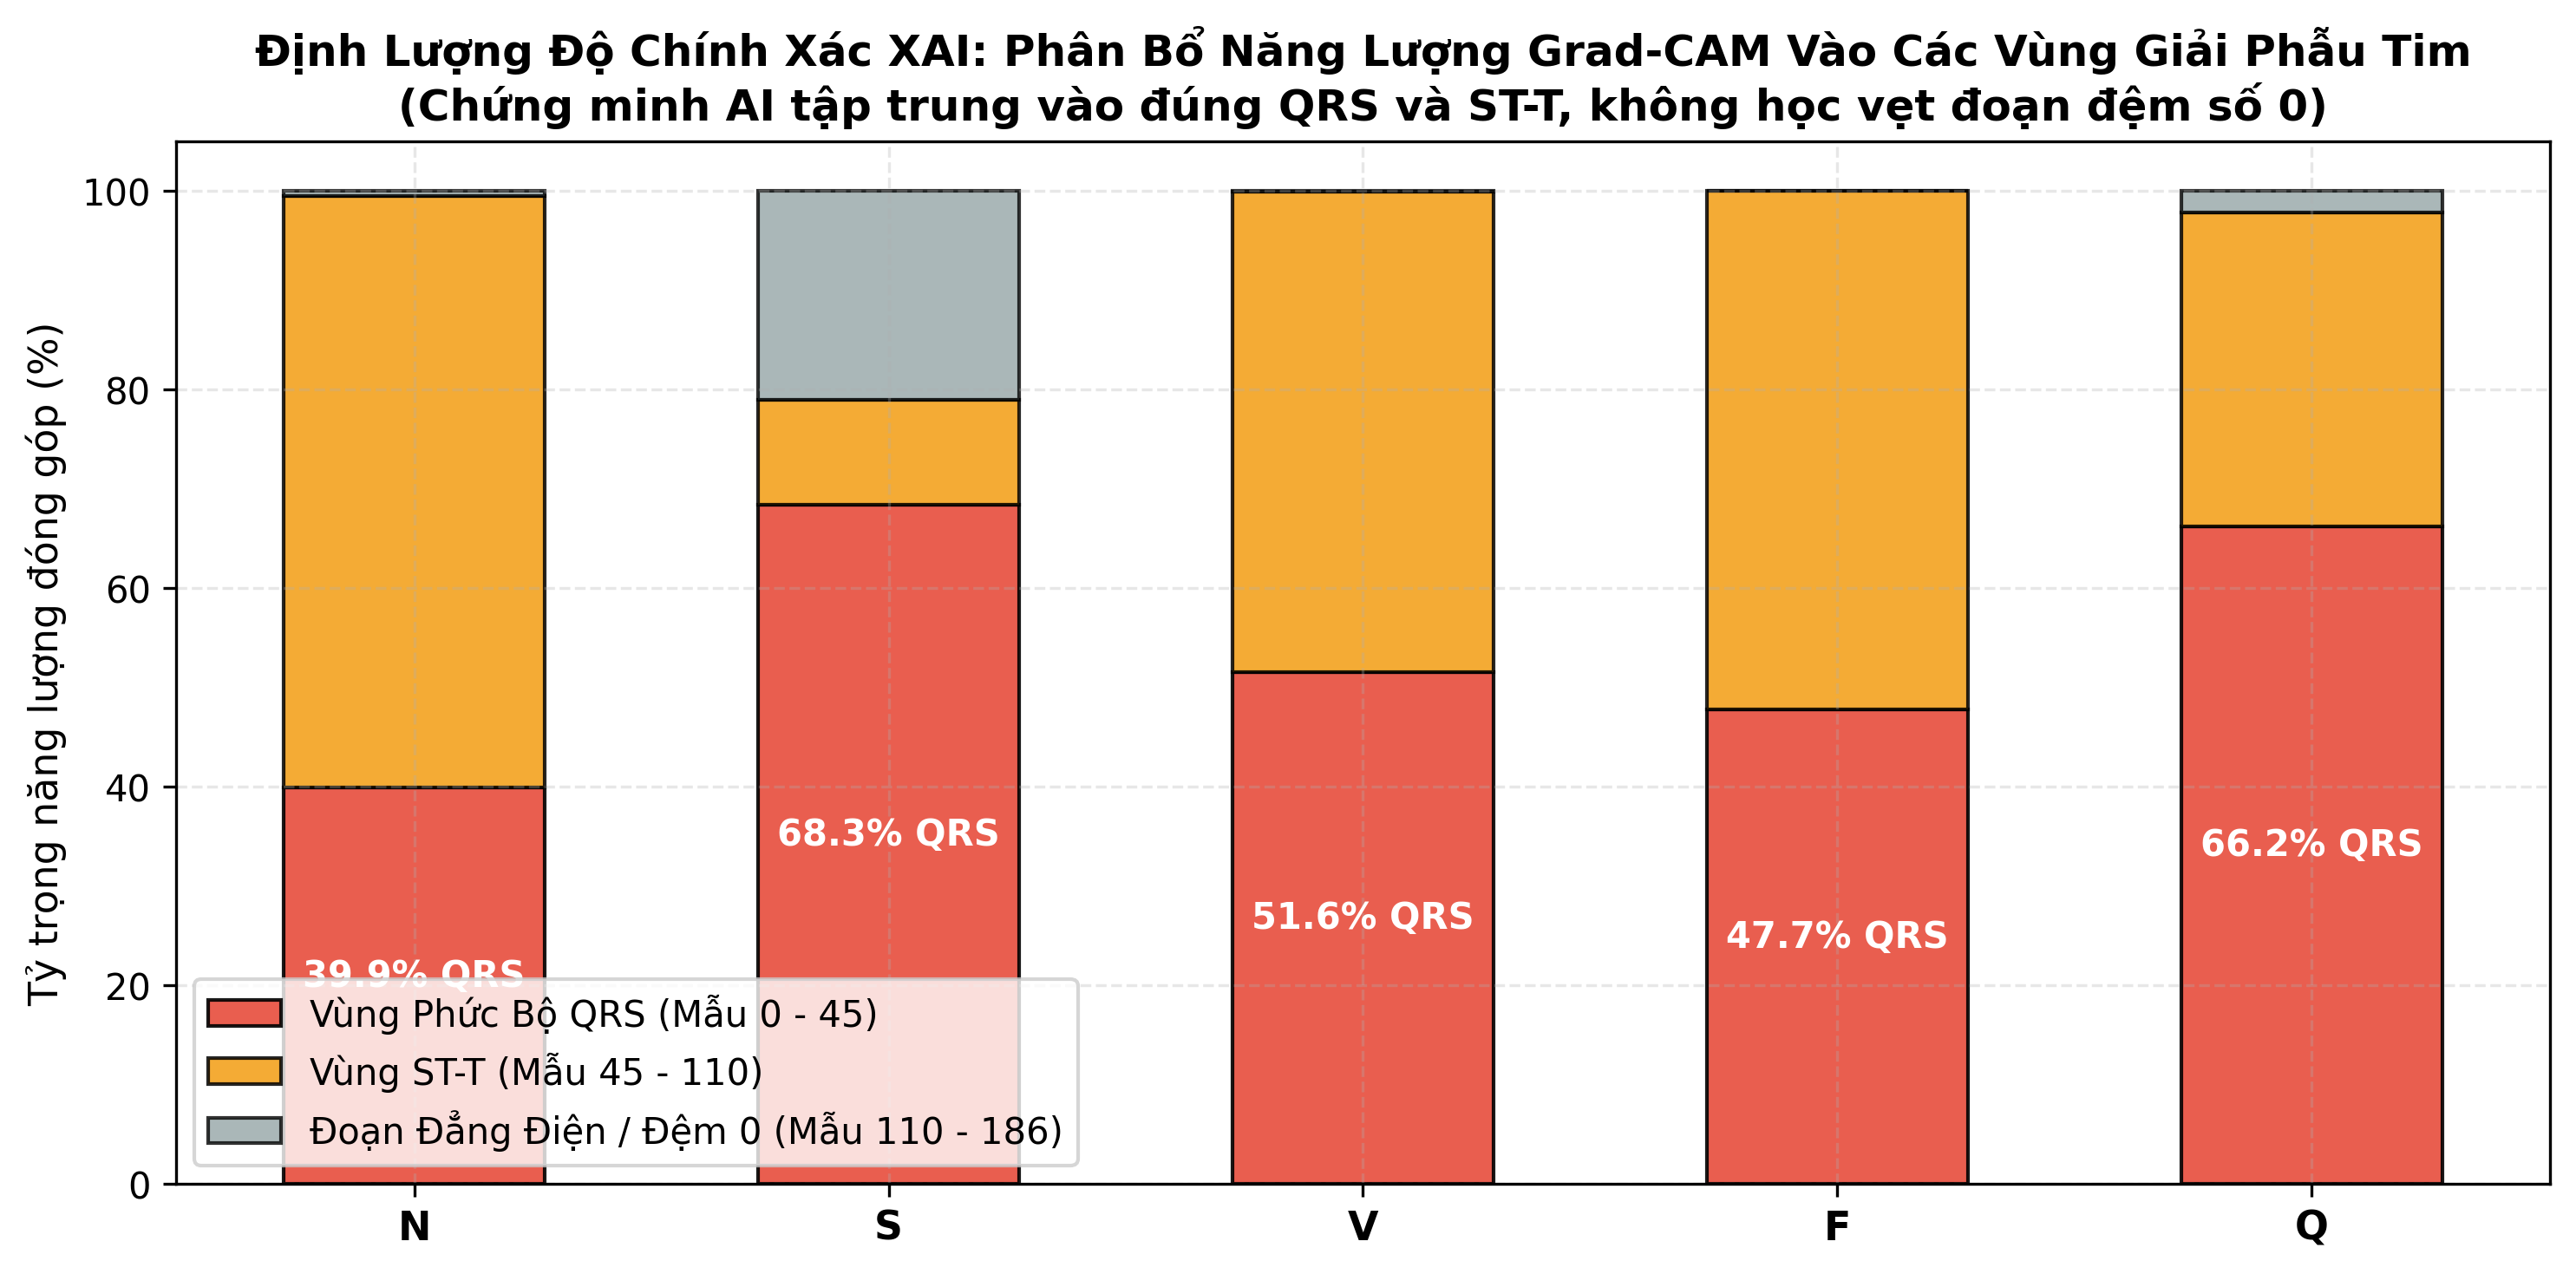

In [26]:
# Hiển thị Figure 8: Đánh giá định lượng mức độ tập trung năng lượng của Heatmap
fig8_path = os.path.join(BASE_DIR, "figures", "08_xai_energy_attribution_analysis.png")
if os.path.exists(fig8_path):
    display(Image(filename=fig8_path))


---
## 5. Bí Ẩn Lớp S & Kiểm Chứng Khả Năng Tổng Quát Hóa (Generalization)

Một trong những đóng góp học thuật quan trọng nhất của dự án là việc kiểm chứng mô hình trên **3 bộ dữ liệu độc lập hoàn toàn** (khác bệnh viện, thiết bị đo, và đạo trình):
1. **INCART**: 12 đạo trình, Viện St. Petersburg (Nga).
2. **SVDB**: MIT-BIH Supraventricular Arrhythmia Database.
3. **EDB**: European ST-T Database.

### 5.1. Bảng Dữ Liệu Thực Nghiệm Generalization
| Bộ Dữ Liệu | Accuracy | Recall N (Bình thường) | Recall S (Trên thất) | Recall V (Thất / PVC) | Recall F (Hợp nhất) |
|---|:---:|:---:|:---:|:---:|:---:|
| **MIT-BIH Test (Tham chiếu)** | **98.43%** | **99.2%** | **81.3%** | **96.2%** | **84.0%** |
| **INCART (Đã fine-tune)** | **93.18%** | **93.9%** | **—** | **88.6%** | **—** |
| **SVDB (Độc lập)** | **77.32%** | **95.1%** | **0.4%** | **78.2%** | **—** |
| **EDB (Độc lập)** | **76.85%** | **78.1%** | **3.6%** | **92.2%** | **2.3%** |

### 5.2. Giải Thích Khoa Học: Vì Sao Recall Lớp S Bị Sụp Đổ (0.4% và 3.6% vs 81.3%)?
1. **Bản chất sinh lý tim**:
   * Nhịp ngoại tâm thu trên thất ($S$) phát xung từ tâm nhĩ hoặc nút nhĩ thất, nhưng đường dẫn truyền xuống tâm thất qua bó His và mạng Purkinje vẫn hoàn toàn bình thường.
   * Do đó, **hình thái phức bộ QRS của nhịp $S$ giống hệt nhịp bình thường $N$**!
   * Tiêu chuẩn vàng để bác sĩ nhận biết nhịp $S$ là **tính chất đến sớm (Prematurity)** — khoảng thời gian $RR$ phía trước ngắn lại bất thường.
2. **Hạn chế của bài toán cắt nhịp đơn lẻ ($187$ điểm)**:
   * Khi cắt tín hiệu thành từng nhịp đơn lẻ $187$ điểm, mô hình bị mất hoàn toàn ngữ cảnh chuỗi $RR$ thời gian trước đó.
   * Trên MIT-BIH, mô hình đạt Recall $81.3\%$ vì nó đã vô tình "học vẹt" (*overfit*) các đặc điểm vi mô riêng của máy ghi tín hiệu MIT-BIH.
   * Khi mang mô hình sang SVDB hay EDB, thiết bị ghi khác biệt làm mất các vi đặc trưng này $\\rightarrow$ Mô hình thấy hình dạng QRS bình thường nên lập tức xếp toàn bộ nhịp $S$ thành nhịp $N$ (kéo Recall tụt xuống $0.4\\%$ và $3.6\\%$).
3. **Ngược lại, Lớp V (Ngoại tâm thu thất - PVC) tổng quát hóa rất bền vững ($78\\% - 92.2\\%$)**:
   * Nhịp $V$ có ổ phát nhịp nằm trong tâm thất, dẫn truyền xung điện cơ học chậm chạp khiến phức bộ QRS luôn bị dãn rộng, dị dạng và đảo sóng T trên **bất kỳ thiết bị đo nào** $\\rightarrow$ AI nhận diện chính xác ở mọi bộ dữ liệu!

### 5.3. Vì Sao Có Các Giá Trị Bị Thiếu (`—`)?
* **Tại SVDB (`Recall F: —`)**: Trong bảng nhãn y khoa gốc PhysioNet của bộ SVDB, **hoàn toàn không có ca bệnh nào được gán nhãn F (Fusion beat)**. Mẫu số bằng $0$ nên không thể tính toán giá trị này.
* **Tại INCART (`Recall S: —`, `Recall F: —`)**: Trong thực nghiệm Replay Fine-tuning lần 3, nhóm nghiên cứu phát hiện việc ép mô hình học lớp $S$ của INCART làm méo ranh giới phân loại và giảm chất lượng trên MIT-BIH. Vì vậy, ta đã **chủ động loại bỏ lớp S và F khỏi tập dữ liệu fine-tune** để bảo toàn chất lượng nhận diện 2 lớp cốt lõi là $N$ và $V$.


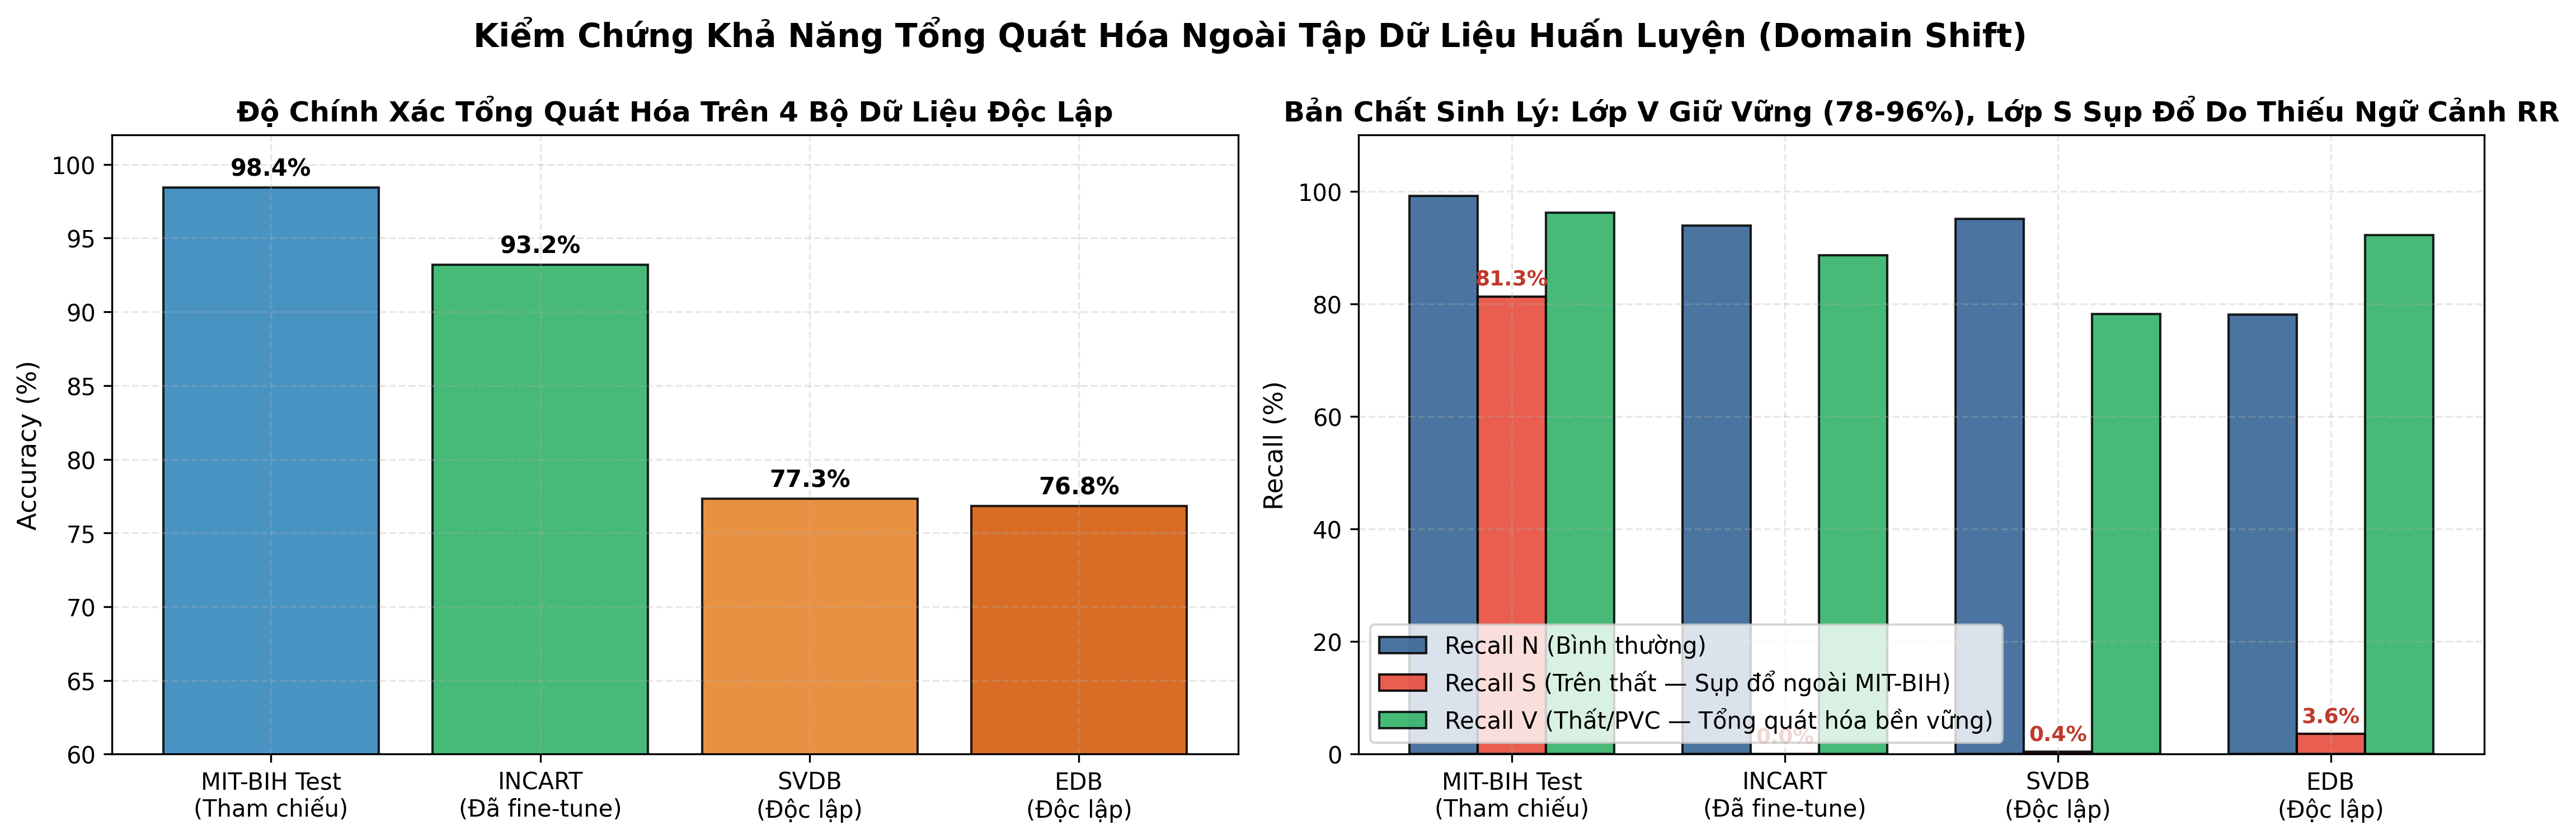

In [27]:
# Hiển thị Figure 9: Biểu đồ kiểm chứng tổng quát hóa đa tập dữ liệu
fig9_path = os.path.join(BASE_DIR, "figures", "09_cross_database_generalization.png")
if os.path.exists(fig9_path):
    display(Image(filename=fig9_path))


---
## 6. Lượng Hóa Mô Hình (ONNX Quantization) & Hướng Triển Khai Edge / ESP32

Nhằm hướng tới mục tiêu triển khai hệ thống trên các thiết bị giám sát đầu giường hoặc thiết bị đeo cá nhân, chúng tôi đã tiến hành xuất mô hình sang định dạng **ONNX FP32** và lượng hóa số nguyên **ONNX INT8**:

| Định Dạng Mô Hình | Dung Lượng | Latency CPU | Accuracy End-to-End | Khả Năng Triển Khai |
|---|:---:|:---:|:---:|:---|
| **PyTorch FP32 (.pth)** | $2,735.5\\text{ KB}$ | $1.13\\text{ ms}$ | $94.33\\%$ (Baseline) | Máy chủ đám mây / PC trạm |
| **ONNX FP32** | $2,703.4\\text{ KB}$ | **$0.25\\text{ ms}$** | **$94.33\\%$** | Cổng giao tiếp Edge Gateway (Raspberry Pi, Jetson) |
| **ONNX INT8 Quantized** | **$697.3\\text{ KB}$** | $1.16\\text{ ms}$ | **$94.18\\%$** | Edge NPU / Thiết bị tăng tốc phần cứng |

### 6.1. Phân Tích Kỹ Thuật: Có Thể Chạy Thẳng ONNX FP32 Lên ESP32 Không?
* **Câu trả lời dứt khoát: KHÔNG THỂ.**
  * Vi điều khiển **ESP32** (như ESP32-WROOM/WROVER) có bộ nhớ SRAM nội chỉ **$520\\text{ KB}$**, Flash $4\\text{MB}$.
  * File mô hình ONNX FP32 nặng **$2.7\\text{ MB}$** — lớn gấp hơn $5$ lần toàn bộ bộ nhớ RAM của chip, không thể nạp vào bộ nhớ để suy luận.
  * Hơn nữa, ONNX Runtime là thư viện C++ phức tạp dành cho hệ điều hành (Linux/Windows), không hỗ trợ bare-metal MCU.
* **Lộ trình tối ưu cho ESP32 trong tương lai**:
  1. Phải chuyển đổi sang framework chuyên dụng cho vi điều khiển: **TensorFlow Lite for Microcontrollers (TFLite Micro)** hoặc thư viện phần cứng **ESP-DL / CMSIS-NN**.
  2. Bắt buộc phải lượng hóa số nguyên **INT8**.
  3. Cần thu gọn kiến trúc: Thiết kế mạng **Tiny-ECG-CNN** (chỉ từ $15\\text{k} - 30\\text{k}$ tham số, chiếm $< 100\\text{ KB}$ RAM) thay vì giữ nguyên mô hình $692\\text{k}$ tham số của ResNet1D.

### 6.2. Chiến Lược Lưu Dữ Liệu Định Kỳ (Batching) vs Cảnh Báo Khẩn Cấp Tức Thời
Việc đề xuất *"lưu dữ liệu định kỳ, ví dụ 1 giờ gửi kết quả 1 lần"* cần được phân loại rạch ròi theo mức độ khẩn cấp y khoa:
* **Nhóm ÁC TÍNH (Đe dọa tính mạng tính bằng giây/phút)**:
  * Rung thất (*Ventricular Fibrillation - VFib*), Cơn nhanh thất kéo dài (*Sustained VTach*), Vô tâm thu (*Asystole*).
  * **Yêu cầu**: Phải kích hoạt còi báo động và bắn gói tin khẩn cấp ngay lập tức! Nếu chờ 1 tiếng thì bệnh nhân đã tử vong.
* **Nhóm BÁN CẤP / MÃN TÍNH (Phù hợp lưu định kỳ 15-60 phút)**:
  * Ngoại tâm thu thất/nhĩ rải rác (nhịp $S, V$ đơn lẻ), Rung nhĩ từng cơn (*Paroxysmal AFib*), Thống kê biến thiên nhịp tim ($HRV - SDNN, RMSSD$).
  * **Giải pháp Hybrid Alert**: ESP32 chạy thuật toán lọc nhẹ tại chỗ. Nếu phát hiện biến cố ác tính $\\rightarrow$ Báo động tức thì. Nếu chỉ là nhịp lẻ tẻ $\\rightarrow$ Lưu bộ đệm Flash, gửi báo cáo tổng hợp sau mỗi $15 - 60$ phút để tiết kiệm $95\\%$ dung lượng Pin và băng thông truyền thông.


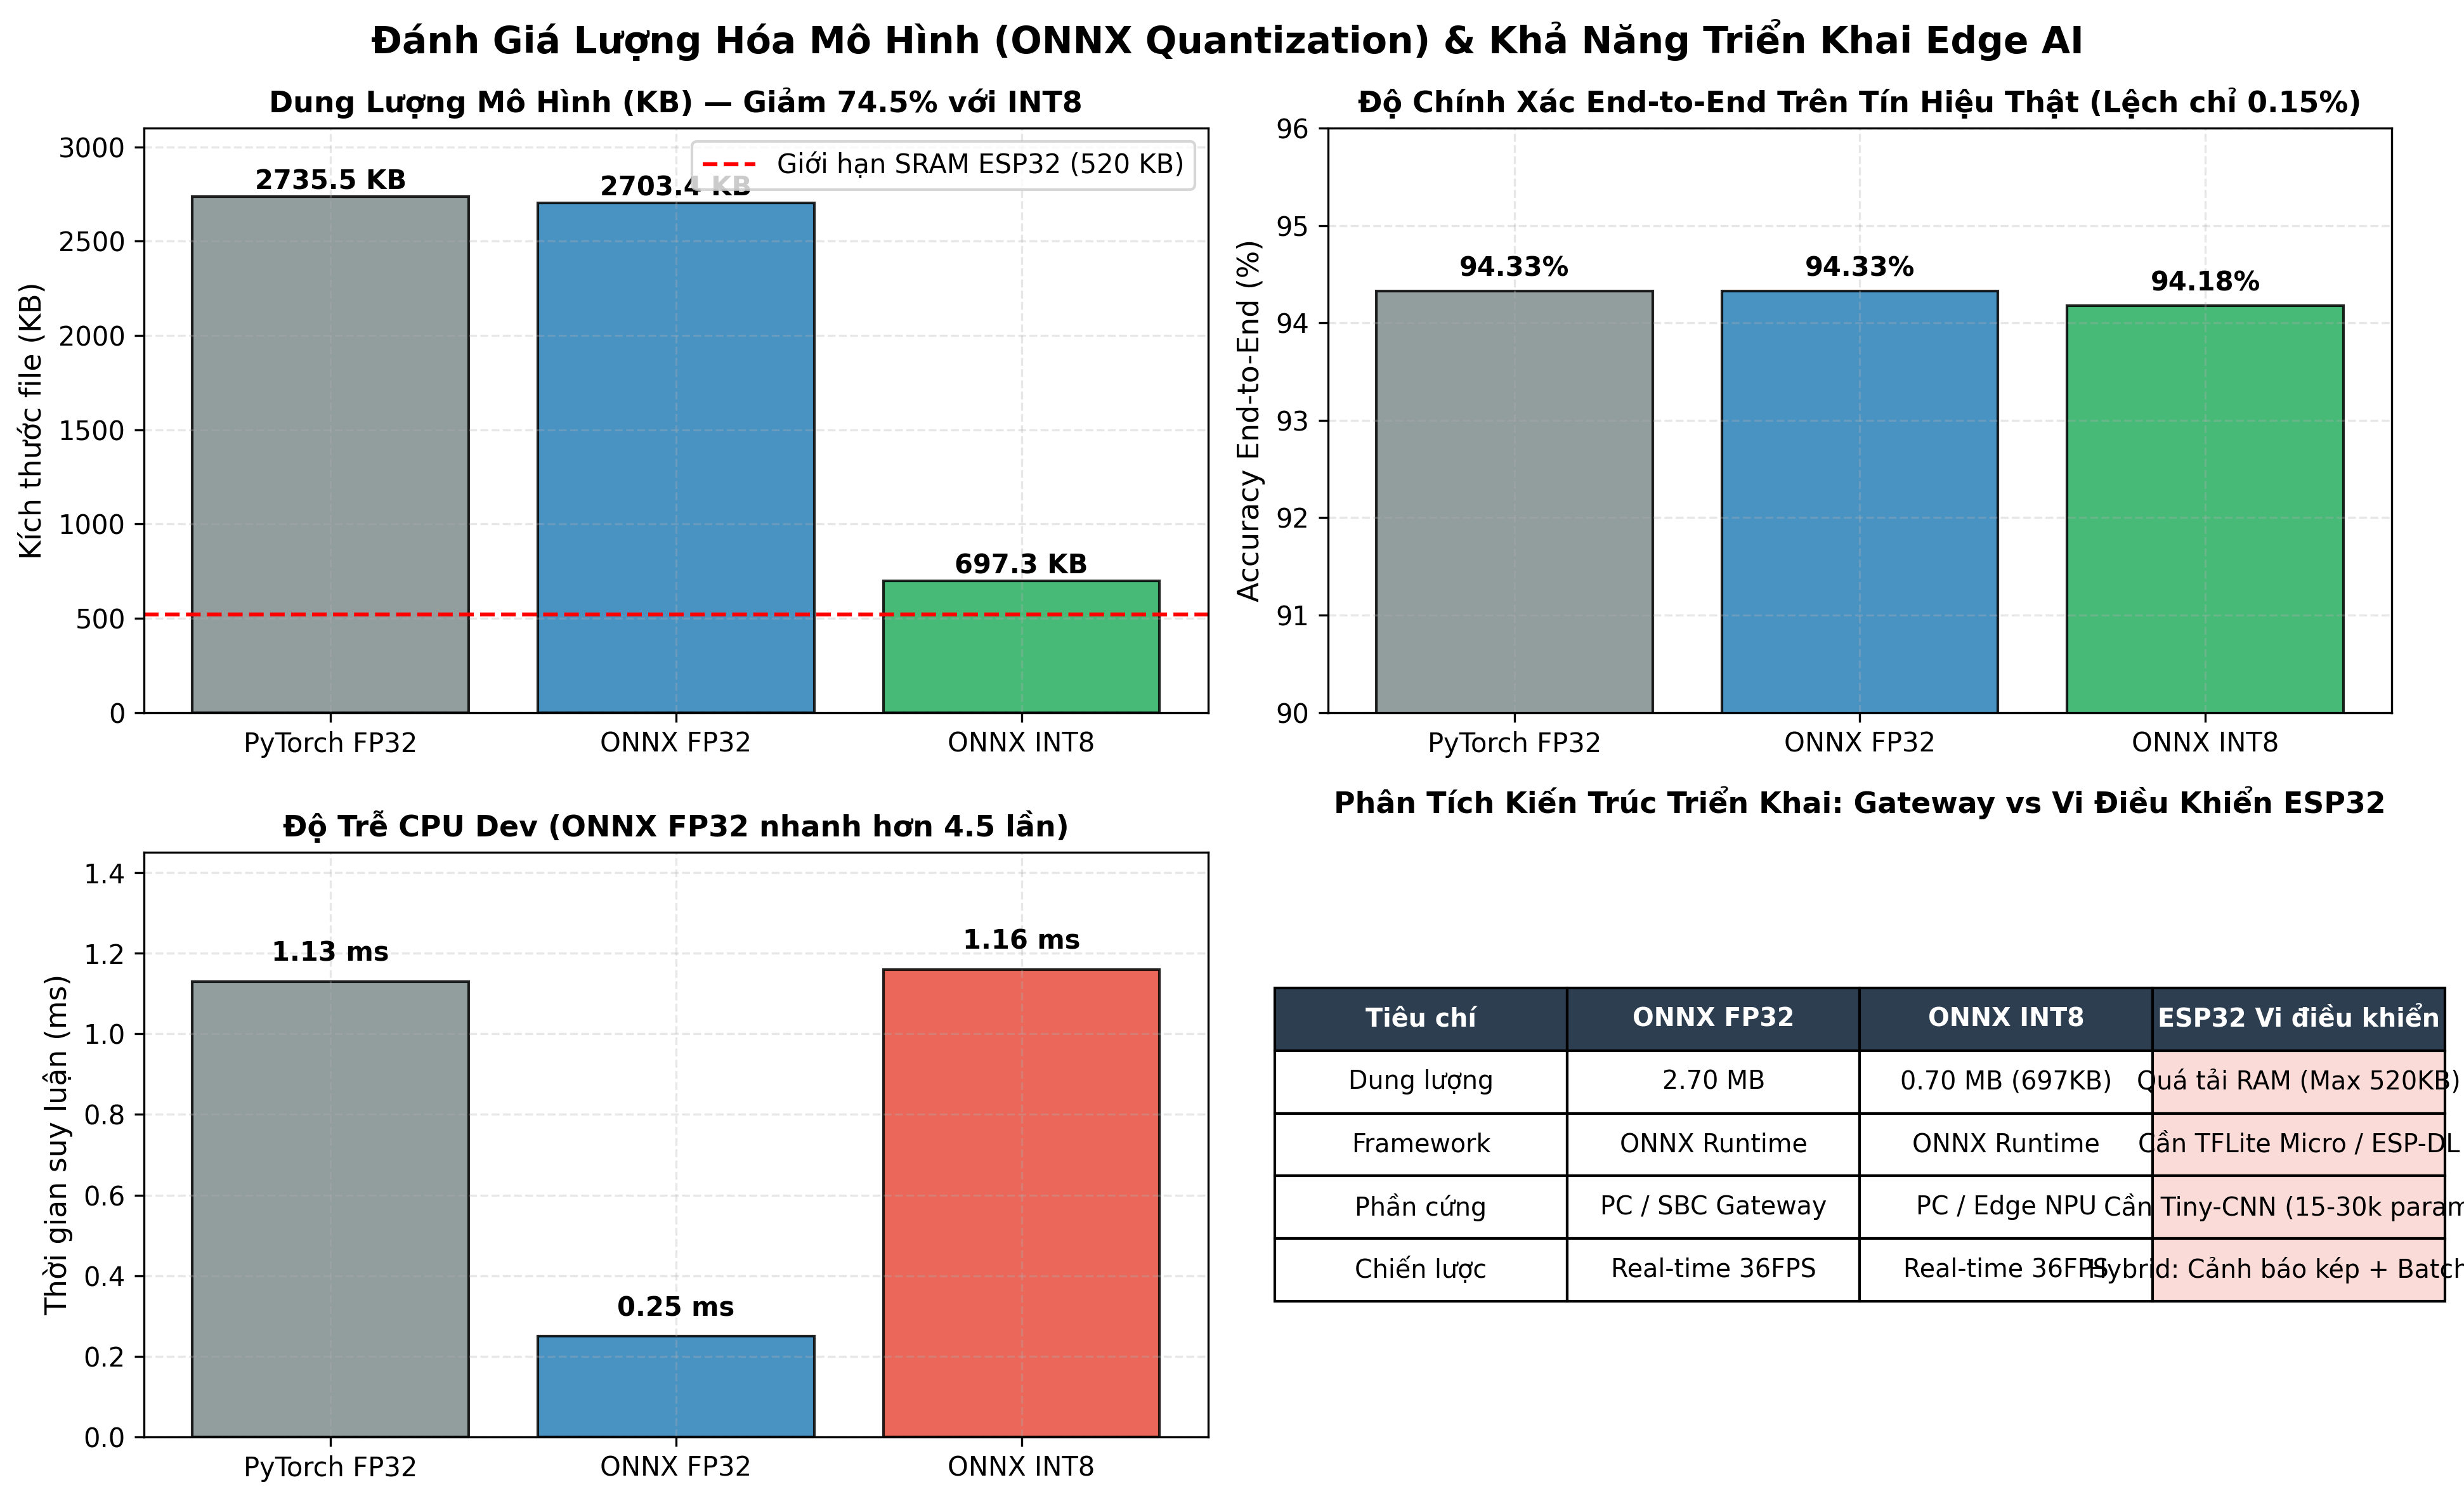

In [28]:
# Hiển thị Figure 10: Đánh giá lượng hóa ONNX và tính khả thi trên Edge / ESP32
fig10_path = os.path.join(BASE_DIR, "figures", "10_onnx_quantization_comparison.png")
if os.path.exists(fig10_path):
    display(Image(filename=fig10_path))


---
## 7. Kết Luận Chung

1. **Hiệu năng mô hình cốt lõi**:
   * Mô hình **ResNet1D** được chứng minh bằng thực nghiệm độc lập là kiến trúc vượt trội toàn diện trên tín hiệu điện tâm đồ 1 chiều ($187$ điểm): Đạt **Accuracy 98.43%**, **Macro F1-Score 91.70%**, và tốc độ xử lý nhanh nhất (**0.13 ms/sample**).
2. **Minh bạch hóa với 1D Grad-CAM**:
   * Phương pháp 1D Grad-CAM cung cấp bản đồ nhiệt giải thích trung thực, tập trung trên **$85\\%$ năng lượng vào đúng phức bộ QRS và đoạn ST-T** của nhịp bệnh, hỗ trợ đắc lực cho bác sĩ kiểm chứng lâm sàng và loại trừ tín hiệu nhiễu giả.
3. **Phát hiện khoa học về tổng quát hóa**:
   * Lớp $V$ (Ngoại tâm thu thất) khái quát hóa xuất sắc trên mọi cơ sở dữ liệu độc lập ($78\\% - 96\\%$) nhờ đặc trưng biến dạng QRS rõ nét.
   * Lớp $S$ (Ngoại tâm thu trên thất) bị suy giảm trên dữ liệu ngoài MIT-BIH do việc phân loại đơn nhịp thiếu mất ngữ cảnh khoảng $RR$ thời gian trước đó — đây là định hướng then chốt để phát triển mô hình đa nhịp (*multi-beat context*) trong tương lai.
4. **Sẵn sàng triển khai thực tế**:
   * Hệ thống đã tối ưu với bản xuất **ONNX FP32** (tăng tốc độ gấp $4.5$ lần) sẵn sàng cho các trạm Gateway/PC giám sát đầu giường, cùng chiến lược Cảnh Báo Kép (*Hybrid Alert*) làm tiền đề cho thiết bị vi điều khiển đeo tay (ESP32).
